# Step 1: Install and Import Required Libraries

In [1]:
# Install required packages
!pip install -q numpy pandas matplotlib seaborn scikit-learn xgboost imbalanced-learn

# Import libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
import xgboost as xgb
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             roc_curve, classification_report)
import warnings
warnings.filterwarnings('ignore')

print("✓ All libraries imported successfully")

✓ All libraries imported successfully


In [2]:
# Sets global seeds across random, numpy, TF, PyTorch
import os, random, numpy as np
os.environ['PYTHONHASHSEED'] = '42'
random.seed(42); np.random.seed(42)
try:
    import tensorflow as tf; tf.random.set_seed(42)
except ImportError: pass
try:
    import torch
    torch.manual_seed(42)
    if torch.cuda.is_available(): torch.cuda.manual_seed_all(42)
except ImportError: pass
print("Seeds set to 42 across numpy / tensorflow / pytorch.")

Seeds set to 42 across numpy / tensorflow / pytorch.


# Step 2: Download and Load Dataset

In [3]:
# Install the required package
!pip install kagglehub

# Authenticate Kaggle (if necessary)
import os
os.environ['KAGGLE_CONFIG_DIR'] = "/path/to/your/kaggle.json"  # Set the correct path

import kagglehub

# Download the dataset
path = kagglehub.dataset_download("shashwatwork/cerebral-stroke-predictionimbalaced-dataset")
print("Path to dataset files:", path)

# List files in directory
import os
print("\nFiles in directory:")
files = os.listdir(path)
for f in files:
    print(f"  - {f}")

# Load the CSV file
csv_file = [f for f in files if f.endswith('.csv')][0]
csv_path = os.path.join(path, csv_file)
df = pd.read_csv(csv_path)


# Load the CSV file into a DataFrame
# Removed the problematic line as csv_path was already correctly defined:
# csv_path = '/root/.cache/kagglehub/datasets/shashwatwork/cerebral-stroke-predictionimbalaced-dataset/versions/1/dataset.csv'
# df = pd.read_csv(csv_path)

100%|██████████| 560k/560k [00:00<00:00, 1.32MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/shashwatwork/cerebral-stroke-predictionimbalaced-dataset/versions/1

Files in directory:
  - dataset.csv


# Step 3: Dataset Overview and Basic Analysis.

## 3.1: Dataset Information

In [4]:
# Show the first few rows to get a quick look at the data
df.head()

# Show dataset info (data types, non-null counts)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43400 entries, 0 to 43399
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 43400 non-null  int64  
 1   gender             43400 non-null  object 
 2   age                43400 non-null  float64
 3   hypertension       43400 non-null  int64  
 4   heart_disease      43400 non-null  int64  
 5   ever_married       43400 non-null  object 
 6   work_type          43400 non-null  object 
 7   Residence_type     43400 non-null  object 
 8   avg_glucose_level  43400 non-null  float64
 9   bmi                41938 non-null  float64
 10  smoking_status     30108 non-null  object 
 11  stroke             43400 non-null  int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 4.0+ MB


## 3.2: Total Dataset Size

In [5]:
# Dataset size (number of elements)
print(f"Total dataset size (number of elements): {df.size}")

# Dataset memory usage (in bytes)
memory_usage = df.memory_usage(deep=True).sum()
print(f"Total memory usage (in bytes): {memory_usage}")

# Memory usage in megabytes (MB)
memory_usage_mb = memory_usage / (1024 ** 2)
print(f"Total memory usage (in MB): {memory_usage_mb:.2f} MB")

Total dataset size (number of elements): 520800
Total memory usage (in bytes): 14095689
Total memory usage (in MB): 13.44 MB


## 3.3: Rows and Columns

In [6]:
# Show the shape of the dataset (rows and columns)
print(f"Total rows: {df.shape[0]}, Total columns: {df.shape[1]}")

Total rows: 43400, Total columns: 12


## 3.4: Numerical vs Categorical Data

In [7]:
# Check if the data columns are numerical or categorical
numerical_cols = df.select_dtypes(include=['number']).columns
categorical_cols = df.select_dtypes(include=['object']).columns

print(f"Numerical Columns: {numerical_cols}")
print(f"Categorical Columns: {categorical_cols}")

Numerical Columns: Index(['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level',
       'bmi', 'stroke'],
      dtype='object')
Categorical Columns: Index(['gender', 'ever_married', 'work_type', 'Residence_type',
       'smoking_status'],
      dtype='object')


## 3.5: Summary Statistics

In [8]:
# Summary statistics for numerical features
df[numerical_cols].describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,43400.000000,43400.000000,43400.000000,43400.000000,43400.000000,41938.000000,43400.000000
mean,36326.142350,42.217894,0.093571,0.047512,104.482750,28.605038,0.018041
std,21072.134879,22.519649,0.291235,0.212733,43.111751,7.770020,0.133103
min,1.000000,0.080000,0.000000,0.000000,55.000000,10.100000,0.000000
25%,18038.500000,24.000000,0.000000,0.000000,77.540000,23.200000,0.000000
50%,36351.500000,44.000000,0.000000,0.000000,91.580000,27.700000,0.000000
75%,54514.250000,60.000000,0.000000,0.000000,112.070000,32.900000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,291.050000,97.600000,1.000000


## 3.6: Dataset Size and Dimensionality

In [9]:
# Dataset size and dimensionality
print(f"Dataset Size: {df.size}")
print(f"Dataset Dimensionality: {df.ndim}")

Dataset Size: 520800
Dataset Dimensionality: 2


## 3.7: Missing Values

In [10]:
# Missing values in the dataset
missing_values = df.isnull().sum()
print(f"Missing Values in the Dataset: \n{missing_values}")

Missing Values in the Dataset: 
id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64


## 3.8: Outliers in Numerical Features

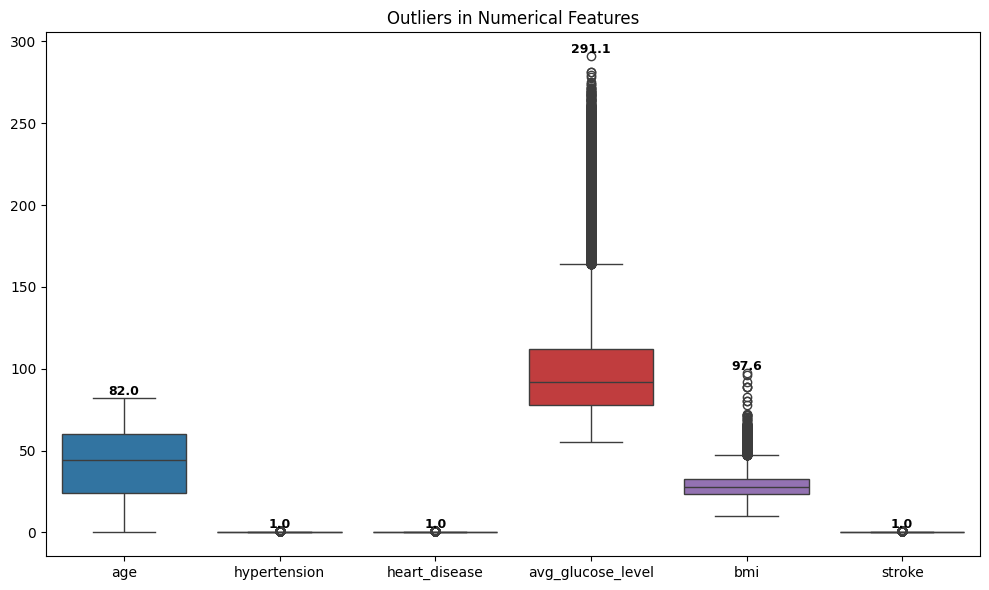

In [11]:
# Check for outliers using boxplot for numerical features (id excluded — skews scale)
plot_cols = [c for c in numerical_cols if c != 'id']

plt.figure(figsize=(10, 6))
ax = sns.boxplot(data=df[plot_cols])
plt.title('Outliers in Numerical Features')

# Annotate each box with its max (top whisker / outlier)
for i, col in enumerate(plot_cols):
    ymax = df[col].max()
    ax.text(i, ymax, f'{ymax:.1f}',
            ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## 3.9: Feature Correlations

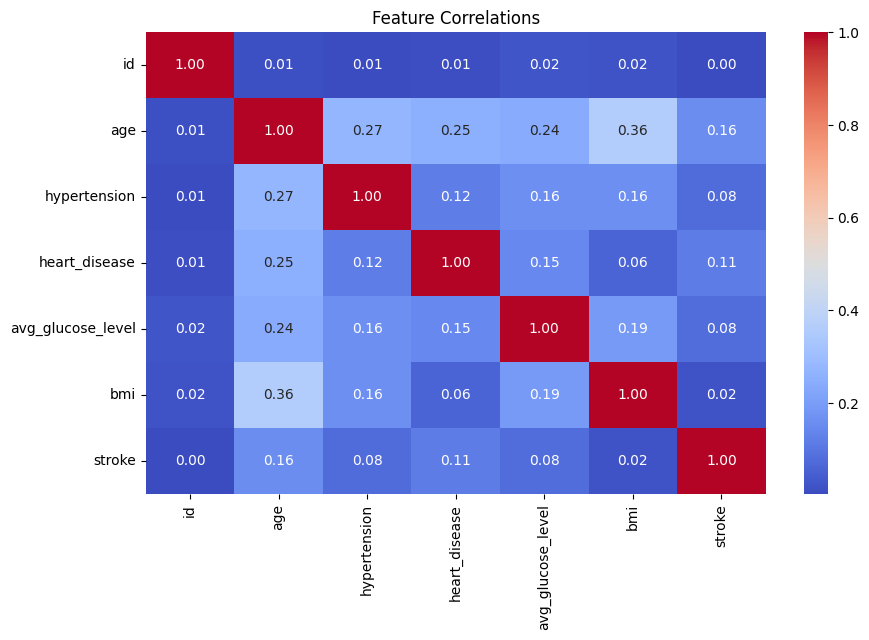

In [12]:
# Feature correlations using a heatmap (only numerical columns)
plt.figure(figsize=(10, 6))
sns.heatmap(df[numerical_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlations')
plt.show()

## 3.10: Skewness of Numerical Features

In [13]:
# Checking skewness in the numerical data
print(f"Skewness of Numerical Features: \n{df[numerical_cols].skew()}")

Skewness of Numerical Features: 
id                   0.004916
age                 -0.102497
hypertension         2.791199
heart_disease        4.254252
avg_glucose_level    1.675405
bmi                  0.898728
stroke               7.242226
dtype: float64


## 3.11: Deduplication and Data Integrity

In [14]:
# Check for duplicate rows
duplicate_rows = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicate_rows}")

# Remove duplicate rows
df_cleaned = df.drop_duplicates()

# Verify the removal of duplicates
print(f"Dataset shape before removing duplicates: {df.shape}")
print(f"Dataset shape after removing duplicates: {df_cleaned.shape}")

Number of duplicate rows: 0
Dataset shape before removing duplicates: (43400, 12)
Dataset shape after removing duplicates: (43400, 12)


# Step 4: Data Preprocessing

## 4.1: Handling Missing Values

In [15]:
print("Missing Values in the Dataset (Before Imputation):")
print(df.isnull().sum())

# using fit_transform on X_train and transform on X_test.
numerical_cols   = df.select_dtypes(include=['number']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print("\nNumerical cols  :", numerical_cols)
print("Categorical cols:", categorical_cols)

# distributions into the train statistics before the split.
print(f"\nDataset shape (unchanged, NaNs still present): {df.shape}")
print("Imputation deferred to Step 8 (train-only fit).")

Missing Values in the Dataset (Before Imputation):
id                       0
gender                   0
age                      0
hypertension             0
heart_disease            0
ever_married             0
work_type                0
Residence_type           0
avg_glucose_level        0
bmi                   1462
smoking_status       13292
stroke                   0
dtype: int64

Numerical cols  : ['id', 'age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi', 'stroke']
Categorical cols: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']

Dataset shape (unchanged, NaNs still present): (43400, 12)
Imputation deferred to Step 8 (train-only fit).


## 4.2: Outlier Detection and Treatment

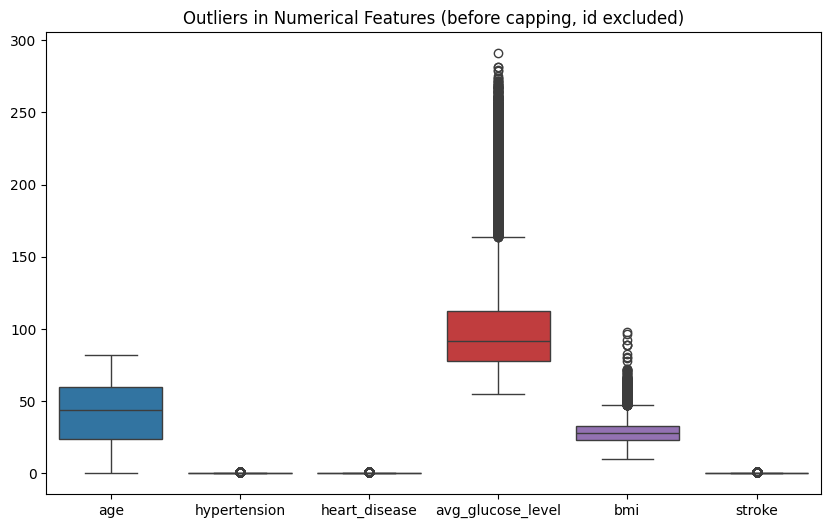

Outlier capping applied at 1st/99th percentile.
Shape after capping: (43400, 12)


In [16]:
import matplotlib.pyplot as plt, seaborn as sns

# CHANGED: drop 'id' from plot only — its huge range (1..72943) flattens every other box.
plot_cols = [c for c in numerical_cols if c != 'id']

plt.figure(figsize=(10, 6))
sns.boxplot(data=df[plot_cols])
plt.title('Outliers in Numerical Features (before capping, id excluded)')
plt.show()

# REMOVED: df_no_outliers block (Z-score path was computed then discarded).

lower_percentile = df[numerical_cols].quantile(0.01)
upper_percentile = df[numerical_cols].quantile(0.99)

# CHANGED: apply capping IN-PLACE on df so downstream cells actually use capped values.
# REMOVED: df_capped = df.copy() — writing straight to df instead
for col in numerical_cols:
    df[col] = df[col].clip(lower=lower_percentile[col], upper=upper_percentile[col])

print("Outlier capping applied at 1st/99th percentile.")
print(f"Shape after capping: {df.shape}")

## 4.3: Categorical Encoding

We use two encoding strategies, both chosen to avoid leakage:

1. **One-Hot Encoding** (applied in Step 4.8.1 on the training split):
   `gender`, `work_type`, `Residence_type`, `smoking_status`.
2. **Ordinal Encoding** (applied in Step 4.8.1 on the training split):
   `ever_married` (binary).

We intentionally do **not** use target encoding on `smoking_status`. Target
encoding replaces each category with the mean of the target variable;
computing that mean on the full dataset leaks test-row labels into the
features of the training set. If target encoding were needed, it would have
to be fit inside a cross-validated pipeline on the training fold only.

This cell is a plan statement — the encoders themselves are created and
fit on `X_train` in Step 4.8.1 (fit-on-train-only pipeline).

In [17]:
# CHANGED: added smoking_status to columns=[...] — drops the leaky target-encoding path entirely.
df_encoded_onehot = pd.get_dummies(
    df, columns=['gender', 'work_type', 'Residence_type', 'smoking_status']
)

# REMOVED: `from sklearn.model_selection import StratifiedKFold` (never used).
# REMOVED: df_target_encoded block — computed target mean on FULL df, leaking y into X.
# REMOVED: target_encoding_map = df.groupby('smoking_status')['stroke'].mean()

print("One-hot encoded columns preview:")
print(df_encoded_onehot.head())
print("Shape:", df_encoded_onehot.shape)


One-hot encoded columns preview:
        id   age  hypertension  heart_disease ever_married  avg_glucose_level  \
0  30669.0   3.0             0              0           No              95.12   
1  30468.0  58.0             1              0          Yes              87.96   
2  16523.0   8.0             0              0           No             110.89   
3  56543.0  70.0             0              0          Yes              69.04   
4  46136.0  14.0             0              0           No             161.28   

    bmi  stroke  gender_Female  gender_Male  ...  work_type_Govt_job  \
0  18.0       0          False         True  ...               False   
1  39.2       0          False         True  ...               False   
2  17.6       0           True        False  ...               False   
3  35.9       0           True        False  ...               False   
4  19.1       0          False         True  ...               False   

   work_type_Never_worked  work_type_Private  w

## 4.4: Visualizations of Categorical Encoding


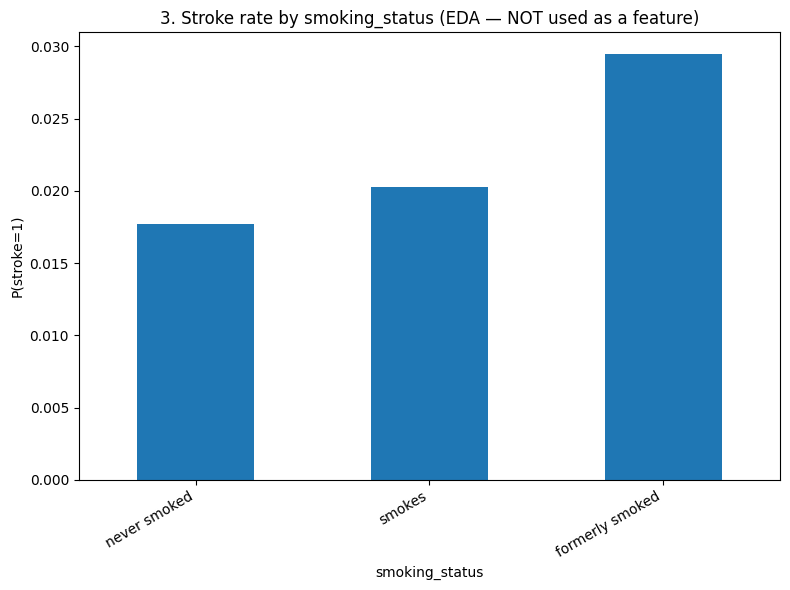

In [18]:
plt.figure(figsize=(8, 6))
stroke_rate_by_smoking = df.groupby('smoking_status')['stroke'].mean().sort_values()
stroke_rate_by_smoking.plot(kind='bar')
plt.title('3. Stroke rate by smoking_status (EDA — NOT used as a feature)')
plt.ylabel('P(stroke=1)')
plt.xlabel('smoking_status')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 4.5: Feature Selection

In [19]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np, pandas as pd

numerical_cols = df_encoded_onehot.select_dtypes(include=['number']).columns.tolist()
# ADDED: exclude target and id from the ranking pool
numerical_cols = [c for c in numerical_cols if c not in ('stroke', 'id')]

# CHANGED: compute actual high-correlation pairs (upper triangle only).
# Old code's `correlation_matrix[... > 0.9].index` returned EVERY column label.
corr = df_encoded_onehot[numerical_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = [(c1, c2, upper.loc[c1, c2])
                   for c1 in upper.index for c2 in upper.columns
                   if pd.notna(upper.loc[c1, c2]) and upper.loc[c1, c2] > 0.9]
print("Highly correlated pairs (|r| > 0.9):", high_corr_pairs)

# REMOVED: df_selected = df_encoded_onehot.drop(columns=highly_correlated)
#          (never used downstream, so the no-op drop is gone)

# CHANGED: added random_state=42 for reproducibility.
# NOTE: this RF fit is on FULL data — that's fine because feature_importances is
# display-only (EDA). Nothing downstream uses it for feature selection.
display_rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
display_rf.fit(df_encoded_onehot[numerical_cols], df_encoded_onehot['stroke'])

feature_importances = pd.DataFrame(
    {'feature': numerical_cols, 'importance': display_rf.feature_importances_}
).sort_values('importance', ascending=False)
print("\nFeature importance (display-only, EDA):")
print(feature_importances.head(10))


Highly correlated pairs (|r| > 0.9): []

Feature importance (display-only, EDA):
             feature  importance
3  avg_glucose_level    0.492574
4                bmi    0.305126
0                age    0.175046
1       hypertension    0.014380
2      heart_disease    0.012875


## 4.6: Feature Scaling

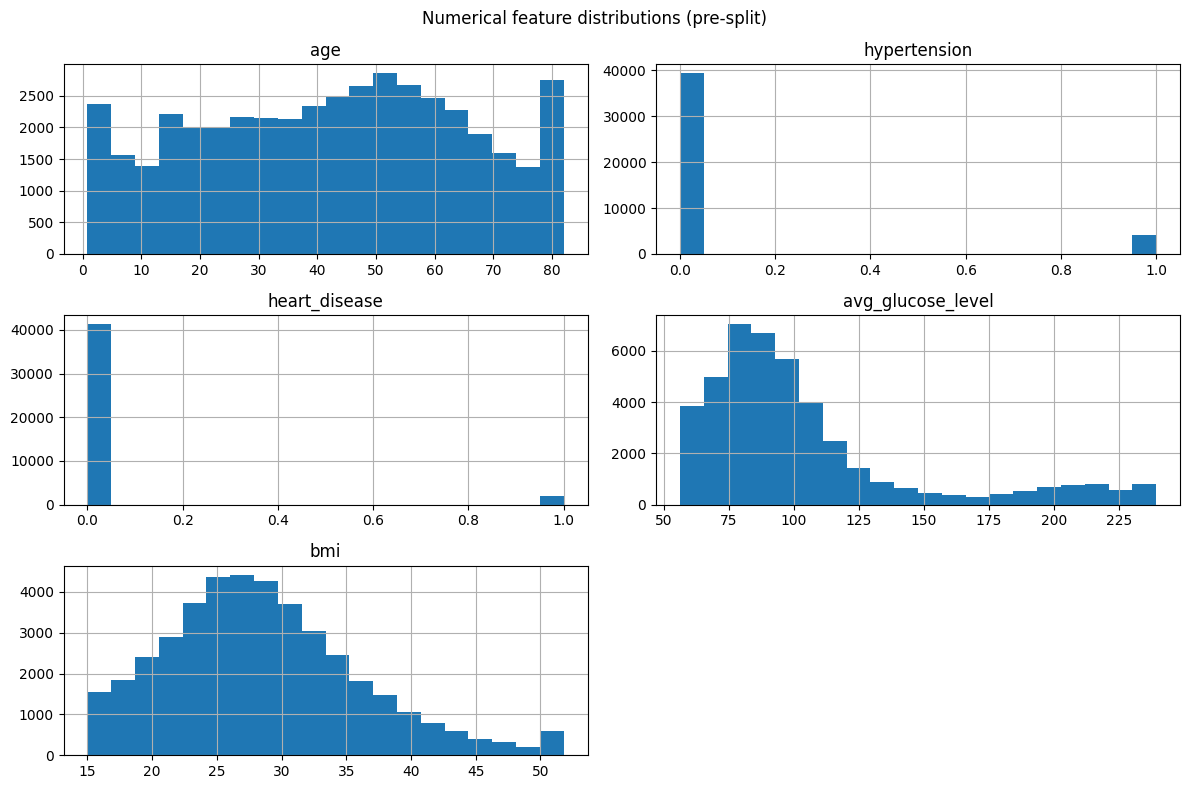

Note: StandardScaler is fit on X_train only in Step 8 (Cell 45).


In [20]:
import matplotlib.pyplot as plt

df[numerical_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle('Numerical feature distributions (pre-split)')
plt.tight_layout()
plt.show()

# REMOVED: StandardScaler.fit_transform(df[...]) — fit on full data = leakage,
# and df_scaled was never used downstream anyway.
# REMOVED: "After Scaling" hist plot (the proper scaler is fit on X_train in Step 8).
print("Note: StandardScaler is fit on X_train only in Step 8 (Cell 45).")


## 4.7: Data Splitting

In [21]:
from sklearn.model_selection import train_test_split

# ADDED: drop 'id' (patient identifier, zero predictive signal).
# Defensive `in df.columns` so this cell is re-runnable.
if 'id' in df.columns:
    df = df.drop(columns='id')
    print("Dropped 'id' column.")
else:
    print("'id' already dropped.")

X = df.drop(columns='stroke')
y = df['stroke']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)
print("\nClass distribution (train):\n", y_train.value_counts(normalize=True))
print("Class distribution (test):\n",   y_test.value_counts(normalize=True))


Dropped 'id' column.
Training set shape: (34720, 10)
Testing set shape : (8680, 10)

Class distribution (train):
 stroke
0    0.98197
1    0.01803
Name: proportion, dtype: float64
Class distribution (test):
 stroke
0    0.981912
1    0.018088
Name: proportion, dtype: float64


## 4.8: Feature Engineering: Scaling, Normalization, and Standardization

### 4.8.1: Feature Scaling for Gradient Descent-Based Algorithm

In [22]:
import pandas as pd, numpy as np
# ADDED: SimpleImputer (was in Cell 30, moved here).
from sklearn.impute import SimpleImputer
# CHANGED: LabelEncoder → OrdinalEncoder (designed for feature columns; handles unseen test values).
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import LogisticRegression

X_train_fe = X_train.copy()
X_test_fe  = X_test.copy()

# ─────────────────────────────────────────────────────────────
# (1) IMPUTE — fit on train only
# ─────────────────────────────────────────────────────────────
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

num_cols = X_train_fe.select_dtypes(include=['number']).columns.tolist()
cat_cols = X_train_fe.select_dtypes(include=['object']).columns.tolist()

X_train_fe[num_cols] = num_imputer.fit_transform(X_train_fe[num_cols])
X_test_fe[num_cols]  = num_imputer.transform(X_test_fe[num_cols])
X_train_fe[cat_cols] = cat_imputer.fit_transform(X_train_fe[cat_cols])
X_test_fe[cat_cols]  = cat_imputer.transform(X_test_fe[cat_cols])
print(f"After imputation — train NaNs: {X_train_fe.isnull().sum().sum()}, test NaNs: {X_test_fe.isnull().sum().sum()}")

# ─────────────────────────────────────────────────────────────
# (2) OUTLIER CAPPING — bounds computed on train, applied to test
# ─────────────────────────────────────────────────────────────
lower_p = X_train_fe[num_cols].quantile(0.01)
upper_p = X_train_fe[num_cols].quantile(0.99)
for col in num_cols:
    X_train_fe[col] = X_train_fe[col].clip(lower=lower_p[col], upper=upper_p[col])
    X_test_fe[col]  = X_test_fe[col].clip(lower=lower_p[col],  upper=upper_p[col])
print("Outlier capping applied at 1st/99th train-percentiles.")

# ─────────────────────────────────────────────────────────────
# (3) ORDINAL ENCODING — one encoder per column
# ─────────────────────────────────────────────────────────────
ever_married_enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
smoking_enc      = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

X_train_fe[['ever_married']]   = ever_married_enc.fit_transform(X_train_fe[['ever_married']])
X_test_fe[['ever_married']]    = ever_married_enc.transform(X_test_fe[['ever_married']])
X_train_fe[['smoking_status']] = smoking_enc.fit_transform(X_train_fe[['smoking_status']])
X_test_fe[['smoking_status']]  = smoking_enc.transform(X_test_fe[['smoking_status']])

# ─────────────────────────────────────────────────────────────
# (4) ONE-HOT ENCODING + column alignment
# ─────────────────────────────────────────────────────────────
X_train_fe = pd.get_dummies(X_train_fe, columns=['gender', 'work_type', 'Residence_type'])
X_test_fe  = pd.get_dummies(X_test_fe,  columns=['gender', 'work_type', 'Residence_type'])
X_train_fe, X_test_fe = X_train_fe.align(X_test_fe, join='left', axis=1, fill_value=0)

# ─────────────────────────────────────────────────────────────
# (5) SCALING — fit on train only
# ─────────────────────────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_fe)
X_test_scaled  = scaler.transform(X_test_fe)

# ─────────────────────────────────────────────────────────────
# (6) SANITY-CHECK LOGISTIC REGRESSION
# ─────────────────────────────────────────────────────────────
logreg = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
logreg.fit(X_train_fe, y_train);      acc_before = logreg.score(X_test_fe, y_test)
logreg.fit(X_train_scaled, y_train);  acc_after  = logreg.score(X_test_scaled, y_test)
print(f"\nAccuracy before scaling: {acc_before:.4f}")
print(f"Accuracy after scaling : {acc_after:.4f}")
print(f"Final feature matrix shape: train {X_train_fe.shape}, test {X_test_fe.shape}")

After imputation — train NaNs: 0, test NaNs: 0
Outlier capping applied at 1st/99th train-percentiles.

Accuracy before scaling: 0.7444
Accuracy after scaling : 0.7435
Final feature matrix shape: train (34720, 17), test (8680, 17)


### 4.8.2: Feature Scaling with Distance-based Algorithm (KNN) - Euclidean and Manhattan

In [23]:

from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

# ----------- Use already encoded data from 4.8.1 -----------
# X_train_fe, X_test_fe are already clean & numeric

# ----------- KNN BEFORE Scaling -----------

# Euclidean
knn_euclidean = KNeighborsClassifier(n_neighbors=5, metric='euclidean')
knn_euclidean.fit(X_train_fe, y_train)
acc_before_euclidean = knn_euclidean.score(X_test_fe, y_test)

# Manhattan
knn_manhattan = KNeighborsClassifier(n_neighbors=5, metric='manhattan')
knn_manhattan.fit(X_train_fe, y_train)
acc_before_manhattan = knn_manhattan.score(X_test_fe, y_test)

# ----------- Apply Scaling -----------

scaler_knn = StandardScaler()

X_train_scaled_knn = scaler_knn.fit_transform(X_train_fe)
X_test_scaled_knn = scaler_knn.transform(X_test_fe)

# ----------- KNN AFTER Scaling -----------

# Euclidean
knn_euclidean.fit(X_train_scaled_knn, y_train)
acc_after_euclidean = knn_euclidean.score(X_test_scaled_knn, y_test)

# Manhattan
knn_manhattan.fit(X_train_scaled_knn, y_train)
acc_after_manhattan = knn_manhattan.score(X_test_scaled_knn, y_test)

# ----------- Results -----------

print(f"Accuracy BEFORE scaling (Euclidean): {acc_before_euclidean:.4f}")
print(f"Accuracy AFTER scaling (Euclidean): {acc_after_euclidean:.4f}")

print(f"Accuracy BEFORE scaling (Manhattan): {acc_before_manhattan:.4f}")
print(f"Accuracy AFTER scaling (Manhattan): {acc_after_manhattan:.4f}")

Accuracy BEFORE scaling (Euclidean): 0.9813
Accuracy AFTER scaling (Euclidean): 0.9812
Accuracy BEFORE scaling (Manhattan): 0.9806
Accuracy AFTER scaling (Manhattan): 0.9815


### 4.8.3: Normalization (Min-Max Scaling)

In [24]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression

# ----------- Use encoded data -----------
# X_train_fe, X_test_fe already prepared

# Apply Min-Max Scaling
scaler_minmax = MinMaxScaler()

X_train_minmax = scaler_minmax.fit_transform(X_train_fe)
X_test_minmax = scaler_minmax.transform(X_test_fe)

# Logistic Regression model
logreg_norm = LogisticRegression(max_iter=1000)

# Train and evaluate
logreg_norm.fit(X_train_minmax, y_train)
accuracy_after_normalization = logreg_norm.score(X_test_minmax, y_test)

# Result
print(f"Accuracy after normalization (Logistic Regression): {accuracy_after_normalization:.4f}")

Accuracy after normalization (Logistic Regression): 0.9819


### 4.8.4: Standardization (Z-Score Scaling)

In [25]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ----------- Use encoded data -----------
# X_train_fe, X_test_fe already prepared

# Apply StandardScaler
scaler_standard = StandardScaler()

X_train_standard = scaler_standard.fit_transform(X_train_fe)
X_test_standard = scaler_standard.transform(X_test_fe)

# Logistic Regression model
logreg_std = LogisticRegression(max_iter=1000)

# Train and evaluate
logreg_std.fit(X_train_standard, y_train)
accuracy_after_standardization = logreg_std.score(X_test_standard, y_test)

# Result
print(f"Accuracy after standardization (Logistic Regression): {accuracy_after_standardization:.4f}")

Accuracy after standardization (Logistic Regression): 0.9819


# Step 5: Linear Regression with Filter Methods

### ⚠️ Note on Model Selection

The given dataset is a **classification problem** (stroke prediction: 0 or 1). Therefore, models like **Logistic Regression** are more appropriate for this task.

However, for the purpose of this project, **Linear Regression is used to demonstrate and apply various filter-based feature selection techniques** that were covered in the lab sessions.

This allows us to understand how different feature selection methods influence model performance, even though Linear Regression is not the ideal choice for binary classification problems.

### Selected Filter Methods

Based on the characteristics of the dataset (binary classification, mixed feature types, and imbalanced target), the following filter methods were selected:

- **Pearson Correlation** → to capture linear relationships between features and target  
- **Variance Threshold** → to remove low-variance (less informative) features  
- **Mutual Information** → to capture non-linear dependencies between features and target  
- **Chi-Square Test** → suitable for categorical features in classification tasks  

These methods are effective for this dataset as they handle both numerical and categorical features and provide meaningful feature importance for classification problems.

## 5.1: Pearson Correlation Coefficient

Selected Features (Pearson): ['age', 'heart_disease', 'avg_glucose_level', 'hypertension', 'ever_married']
ROC-AUC: 0.8385
PR-AUC : 0.0800


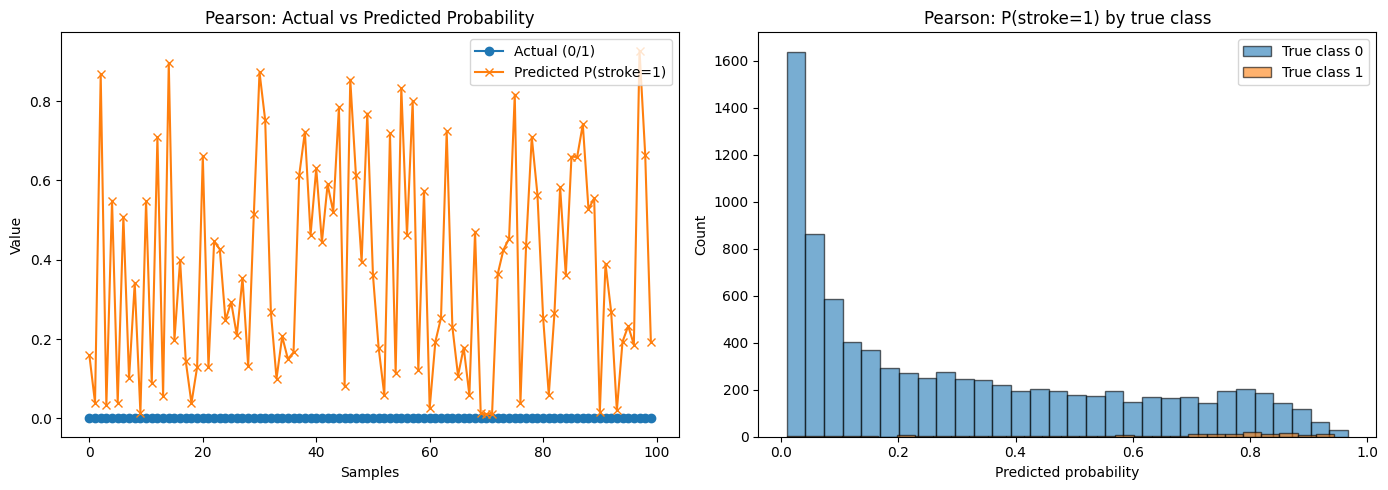

In [26]:
# Step 5.1 — Pearson Correlation filter (full fixed cell)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
# CHANGED: LinearRegression → LogisticRegression (target is binary 0/1).
# CHANGED: MSE/R² → ROC-AUC/PR-AUC (regression metrics on a classifier are meaningless).
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# ----- Feature selection: top-5 by |Pearson corr| with target -----
train_df = X_train_fe.copy()
train_df['stroke'] = y_train
correlation = train_df.corr()['stroke'].abs().sort_values(ascending=False)
selected_features = correlation.index[1:6]      # skip target itself
print("Selected Features (Pearson):", list(selected_features))

X_train_sel = X_train_fe[selected_features]
X_test_sel  = X_test_fe[selected_features]

# ----- Model: LogisticRegression (class_weight='balanced' for 98/2 imbalance) -----
lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr.fit(X_train_sel, y_train)

# CHANGED: predict both probabilities (for AUC) and hard labels.
y_proba = lr.predict_proba(X_test_sel)[:, 1]
y_pred  = lr.predict(X_test_sel)

# ----- Evaluation: imbalance-appropriate metrics -----
pearson_auc = roc_auc_score(y_test, y_proba)
pearson_ap  = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {pearson_auc:.4f}")
print(f"PR-AUC : {pearson_ap:.4f}")

# ----- Visualization (adapted to classifier outputs) -----
plt.figure(figsize=(14, 5))

# CHANGED: "Actual vs Predicted" now plots predicted PROBABILITIES
# (more informative than hard 0/1 labels for a classifier).
plt.subplot(1, 2, 1)
plt.plot(y_test.values[:100], label="Actual (0/1)",          marker='o')
plt.plot(y_proba[:100],        label="Predicted P(stroke=1)", marker='x')
plt.title("Pearson: Actual vs Predicted Probability")
plt.xlabel("Samples"); plt.ylabel("Value"); plt.legend()

# CHANGED: residuals → probability distribution split by true class.
# (Residuals don't make sense for a classifier; this visualizes class separation.)
plt.subplot(1, 2, 2)
plt.hist(y_proba[y_test == 0], bins=30, alpha=0.6, label='True class 0', edgecolor='black')
plt.hist(y_proba[y_test == 1], bins=30, alpha=0.6, label='True class 1', edgecolor='black')
plt.title("Pearson: P(stroke=1) by true class")
plt.xlabel("Predicted probability"); plt.ylabel("Count"); plt.legend()

plt.tight_layout()
plt.show()

# CHANGED: saved vars renamed (was pearson_mse / pearson_r2 / pearson_y_pred).
# REMOVED: pearson_mse, pearson_r2
pearson_y_proba = y_proba
pearson_y_pred  = y_pred

## 5.2: Variance Threshold

Selected Features (Variance Threshold): ['age', 'hypertension', 'heart_disease', 'ever_married', 'avg_glucose_level', 'bmi', 'smoking_status', 'gender_Female', 'gender_Male', 'work_type_Govt_job', 'work_type_Private', 'work_type_Self-employed', 'work_type_children', 'Residence_type_Rural', 'Residence_type_Urban']
ROC-AUC: 0.8395
PR-AUC : 0.0810


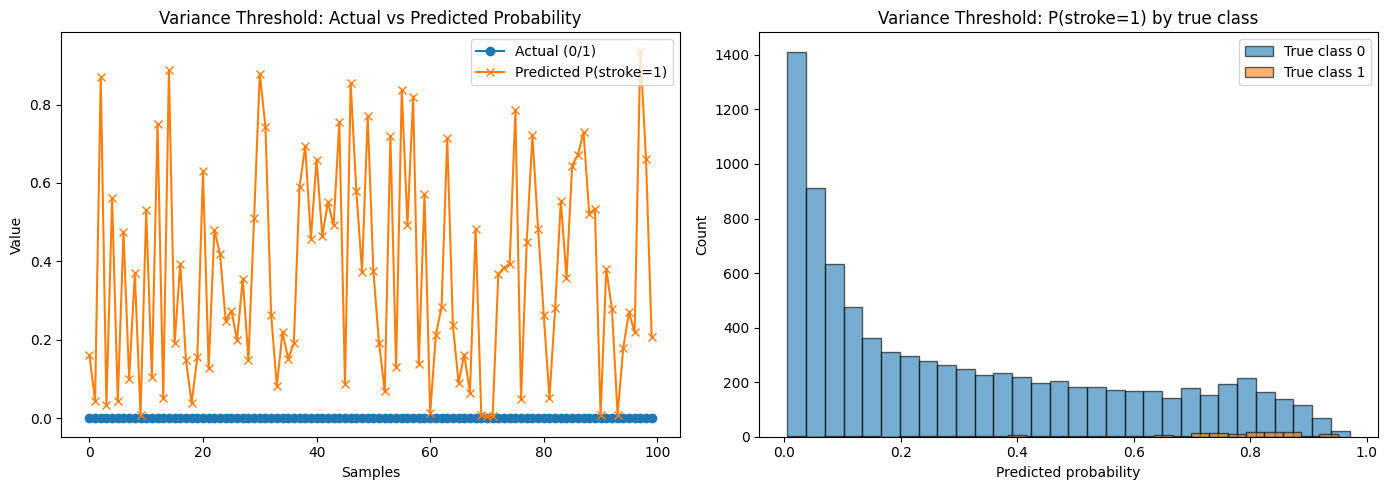

In [27]:
# Step 5.2 — Variance Threshold filter (full fixed cell)
import numpy as np, matplotlib.pyplot as plt
from sklearn.feature_selection import VarianceThreshold
# CHANGED: LinearRegression → LogisticRegression.
# CHANGED: MSE/R² → ROC-AUC/PR-AUC.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# ----- Feature selection: drop near-constant columns (var < 0.01) -----
selector = VarianceThreshold(threshold=0.01)
selector.fit(X_train_fe)
selected_features = X_train_fe.columns[selector.get_support()]
print("Selected Features (Variance Threshold):", list(selected_features))

X_train_sel = X_train_fe[selected_features]
X_test_sel  = X_test_fe[selected_features]

# ----- Model -----
lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr.fit(X_train_sel, y_train)

y_proba = lr.predict_proba(X_test_sel)[:, 1]
y_pred  = lr.predict(X_test_sel)

# ----- Metrics -----
var_auc = roc_auc_score(y_test, y_proba)
var_ap  = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {var_auc:.4f}")
print(f"PR-AUC : {var_ap:.4f}")

# ----- Visualization (same layout as Step 9, labeled for Variance Threshold) -----
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(y_test.values[:100], label="Actual (0/1)",          marker='o')
plt.plot(y_proba[:100],        label="Predicted P(stroke=1)", marker='x')
plt.title("Variance Threshold: Actual vs Predicted Probability")
plt.xlabel("Samples"); plt.ylabel("Value"); plt.legend()

plt.subplot(1, 2, 2)
plt.hist(y_proba[y_test == 0], bins=30, alpha=0.6, label='True class 0', edgecolor='black')
plt.hist(y_proba[y_test == 1], bins=30, alpha=0.6, label='True class 1', edgecolor='black')
plt.title("Variance Threshold: P(stroke=1) by true class")
plt.xlabel("Predicted probability"); plt.ylabel("Count"); plt.legend()

plt.tight_layout()
plt.show()

# CHANGED: saved vars renamed.
# REMOVED: var_mse, var_r2
var_y_proba = y_proba
var_y_pred  = y_pred

## 5.3: Mutual Information

Selected Features (Mutual Information): ['age', 'ever_married', 'Residence_type_Rural', 'Residence_type_Urban', 'gender_Female']
ROC-AUC: 0.8369
PR-AUC : 0.0801


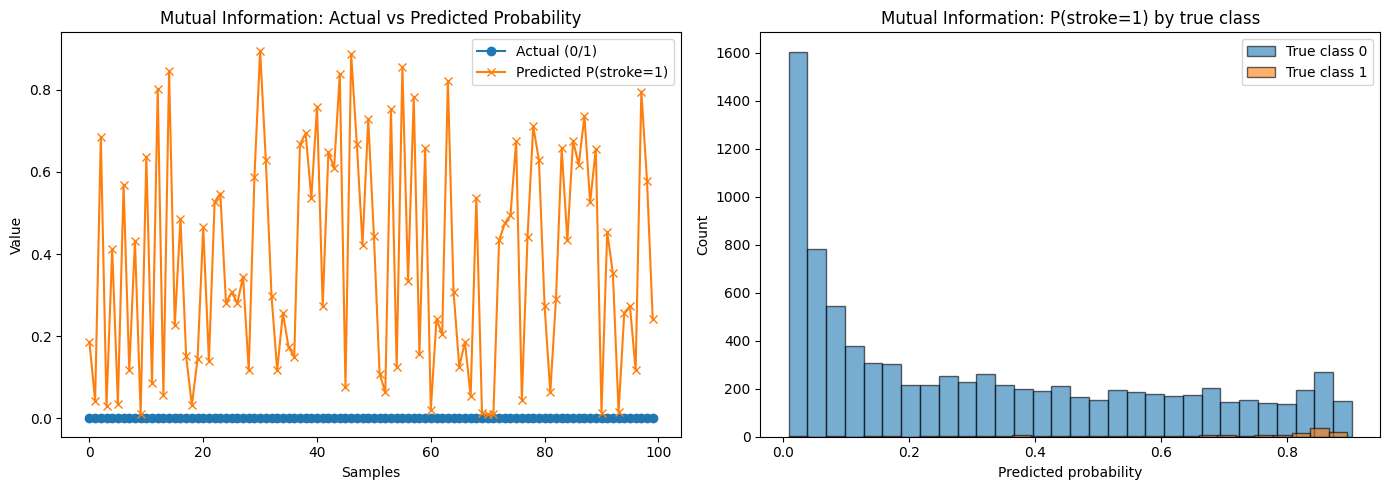

In [28]:
# Step 5.3 — Mutual Information filter (full fixed cell)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_selection import mutual_info_classif
# CHANGED: LinearRegression → LogisticRegression.
# CHANGED: MSE/R² → ROC-AUC/PR-AUC (this ALSO removes the r2_score(y_test, y_test) bug).
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# ----- Feature selection: top-5 by mutual information with target -----
# CHANGED: added random_state=42 to mutual_info_classif for reproducibility.
mi_scores = mutual_info_classif(X_train_fe, y_train, random_state=42)
mi_scores = pd.Series(mi_scores, index=X_train_fe.columns).sort_values(ascending=False)
selected_features = mi_scores.index[:5]
print("Selected Features (Mutual Information):", list(selected_features))

X_train_sel = X_train_fe[selected_features]
X_test_sel  = X_test_fe[selected_features]

# ----- Model -----
lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr.fit(X_train_sel, y_train)

y_proba = lr.predict_proba(X_test_sel)[:, 1]
y_pred  = lr.predict(X_test_sel)

# ----- Metrics -----
mi_auc = roc_auc_score(y_test, y_proba)
mi_ap  = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {mi_auc:.4f}")
print(f"PR-AUC : {mi_ap:.4f}")

# ----- Visualization -----
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(y_test.values[:100], label="Actual (0/1)",          marker='o')
plt.plot(y_proba[:100],        label="Predicted P(stroke=1)", marker='x')
plt.title("Mutual Information: Actual vs Predicted Probability")
plt.xlabel("Samples"); plt.ylabel("Value"); plt.legend()

plt.subplot(1, 2, 2)
plt.hist(y_proba[y_test == 0], bins=30, alpha=0.6, label='True class 0', edgecolor='black')
plt.hist(y_proba[y_test == 1], bins=30, alpha=0.6, label='True class 1', edgecolor='black')
plt.title("Mutual Information: P(stroke=1) by true class")
plt.xlabel("Predicted probability"); plt.ylabel("Count"); plt.legend()

plt.tight_layout()
plt.show()

# CHANGED: saved vars renamed.
# REMOVED: mi_mse, mi_r2 (and the buggy `r2 = r2_score(y_test, y_test)` line is gone).
mi_y_proba = y_proba
mi_y_pred  = y_pred

## 5.4: Chi-Square

Selected Features (Chi-Square): ['age', 'hypertension', 'heart_disease', 'work_type_Self-employed', 'work_type_children']
ROC-AUC: 0.8374
PR-AUC : 0.0833


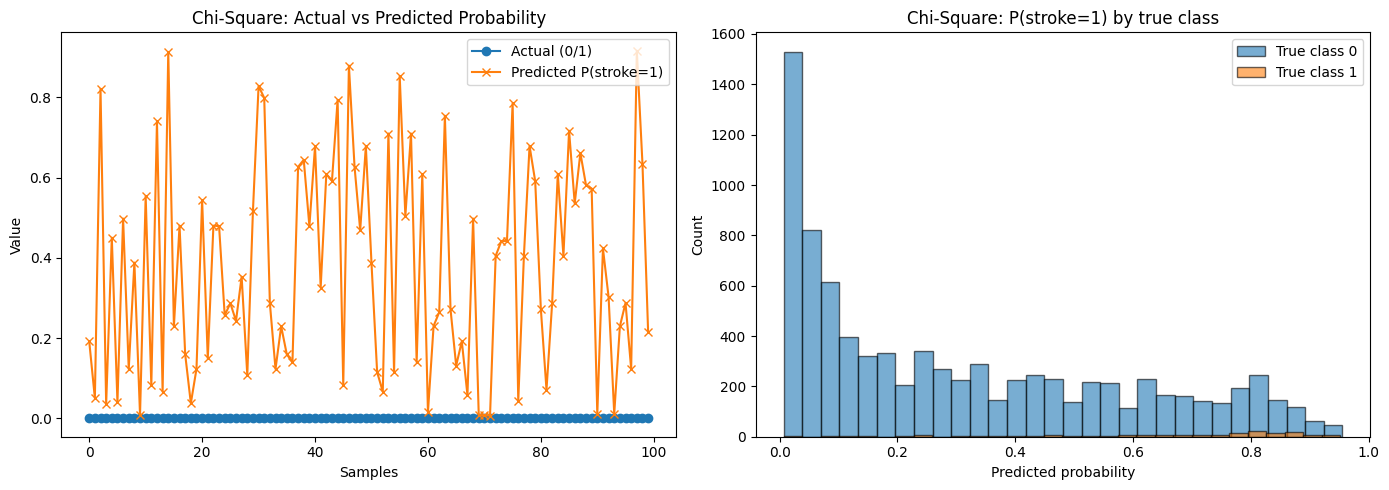

In [29]:
# Step 5.4 — Chi-Square filter (full fixed cell)
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from sklearn.feature_selection import SelectKBest, chi2
# ADDED: MinMaxScaler (fit on train, apply to test) — same non-negative scale on both sets.
from sklearn.preprocessing import MinMaxScaler
# CHANGED: LinearRegression → LogisticRegression.
# CHANGED: MSE/R² → ROC-AUC/PR-AUC.
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score

# ----- Prepare non-negative features (chi² requirement) -----
# CHANGED: the broken "shift by each set's own .min()" block is replaced by a
# train-fit MinMaxScaler so train and test share the same [0,1] scale.
# REMOVED: X_train_chi = X_train_chi - X_train_chi.min()
# REMOVED: X_test_chi  = X_test_chi  - X_test_chi.min()
mm = MinMaxScaler()
X_train_chi = pd.DataFrame(mm.fit_transform(X_train_fe.astype(float)),
                           columns=X_train_fe.columns, index=X_train_fe.index)
X_test_chi  = pd.DataFrame(mm.transform(X_test_fe.astype(float)),
                           columns=X_test_fe.columns,  index=X_test_fe.index)

# ----- Feature selection: top-5 by chi² with target -----
chi_selector = SelectKBest(score_func=chi2, k=5)
chi_selector.fit(X_train_chi, y_train)
selected_features = X_train_fe.columns[chi_selector.get_support()]
print("Selected Features (Chi-Square):", list(selected_features))

X_train_sel = X_train_chi[selected_features]
X_test_sel  = X_test_chi[selected_features]

# ----- Model -----
lr = LogisticRegression(max_iter=2000, class_weight='balanced', random_state=42)
lr.fit(X_train_sel, y_train)

y_proba = lr.predict_proba(X_test_sel)[:, 1]
y_pred  = lr.predict(X_test_sel)

# ----- Metrics -----
chi_auc = roc_auc_score(y_test, y_proba)
chi_ap  = average_precision_score(y_test, y_proba)
print(f"ROC-AUC: {chi_auc:.4f}")
print(f"PR-AUC : {chi_ap:.4f}")

# ----- Visualization -----
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(y_test.values[:100], label="Actual (0/1)",          marker='o')
plt.plot(y_proba[:100],        label="Predicted P(stroke=1)", marker='x')
plt.title("Chi-Square: Actual vs Predicted Probability")
plt.xlabel("Samples"); plt.ylabel("Value"); plt.legend()

plt.subplot(1, 2, 2)
plt.hist(y_proba[y_test == 0], bins=30, alpha=0.6, label='True class 0', edgecolor='black')
plt.hist(y_proba[y_test == 1], bins=30, alpha=0.6, label='True class 1', edgecolor='black')
plt.title("Chi-Square: P(stroke=1) by true class")
plt.xlabel("Predicted probability"); plt.ylabel("Count"); plt.legend()

plt.tight_layout()
plt.show()

# CHANGED: saved vars renamed.
# REMOVED: chi_mse, chi_r2
chi_y_proba = y_proba
chi_y_pred  = y_pred

### Excluded Filter Methods and Justification

Some filter methods were not included in this analysis due to their limited relevance to the dataset:

- **Fisher Score** → Although useful for classification, it is more suitable for continuous and well-separated class distributions. It is less commonly used in practical machine learning pipelines and requires additional implementation complexity.

- **Dispersion Ratio** → This method is not widely used in modern machine learning workflows and does not provide significant advantages over simpler and more interpretable techniques like variance threshold.

- **MAD (Median Absolute Deviation)** → While useful for detecting outliers, it is not a direct feature selection technique and does not strongly contribute to improving model performance in this context.

Therefore, only the most relevant and effective filter methods were selected to ensure a clear and meaningful analysis.

## 5.5: Comparison Table

In [30]:
import pandas as pd

results = {
    "Method":  ["Pearson", "Variance Threshold", "Mutual Information", "Chi-Square"],
    "ROC-AUC": [pearson_auc, var_auc, mi_auc, chi_auc],
    "PR-AUC":  [pearson_ap,  var_ap,  mi_ap,  chi_ap],
}
results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
print("Filter Method Comparison:")
print(results_df.to_string(index=False))

Filter Method Comparison:
            Method  ROC-AUC   PR-AUC
Variance Threshold 0.839455 0.080974
           Pearson 0.838521 0.080003
        Chi-Square 0.837427 0.083314
Mutual Information 0.836863 0.080051


## 5.6: One GLOBAL Regression Line

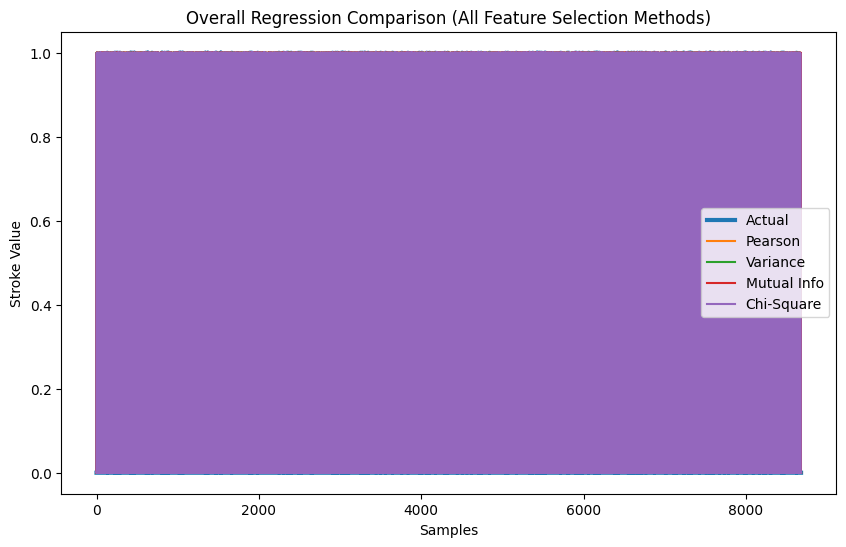

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

# Use same test index for fairness
x_axis = range(len(y_test))

# Actual values (same for all)
plt.plot(x_axis, y_test.values, label="Actual", linewidth=3)

# Predictions from all methods
plt.plot(x_axis, pearson_y_pred, label="Pearson")
plt.plot(x_axis, var_y_pred, label="Variance")
plt.plot(x_axis, mi_y_pred, label="Mutual Info")
plt.plot(x_axis, chi_y_pred, label="Chi-Square")

plt.title("Overall Regression Comparison (All Feature Selection Methods)")
plt.xlabel("Samples")
plt.ylabel("Stroke Value")
plt.legend()

plt.show()

# Step 6: Implementation of Logistic Regression model

## 6.1: Dataset Condition After Preprocessing

In [32]:
import pandas as pd

# Dataset overview after preprocessing
print("Dataset Shape:", X_train_fe.shape)

print("\nData Types:")
print(X_train_fe.dtypes)

print("\nMissing Values Check:")
print(X_train_fe.isnull().sum().sum())

print("\nClass Balance (Target):")
print(y_train.value_counts())

Dataset Shape: (34720, 17)

Data Types:
age                        float64
hypertension               float64
heart_disease              float64
ever_married               float64
avg_glucose_level          float64
bmi                        float64
smoking_status             float64
gender_Female                 bool
gender_Male                   bool
gender_Other                  bool
work_type_Govt_job            bool
work_type_Never_worked        bool
work_type_Private             bool
work_type_Self-employed       bool
work_type_children            bool
Residence_type_Rural          bool
Residence_type_Urban          bool
dtype: object

Missing Values Check:
0

Class Balance (Target):
stroke
0    34094
1      626
Name: count, dtype: int64


## 6.2: Correlation Analysis + Multicollinearity Check

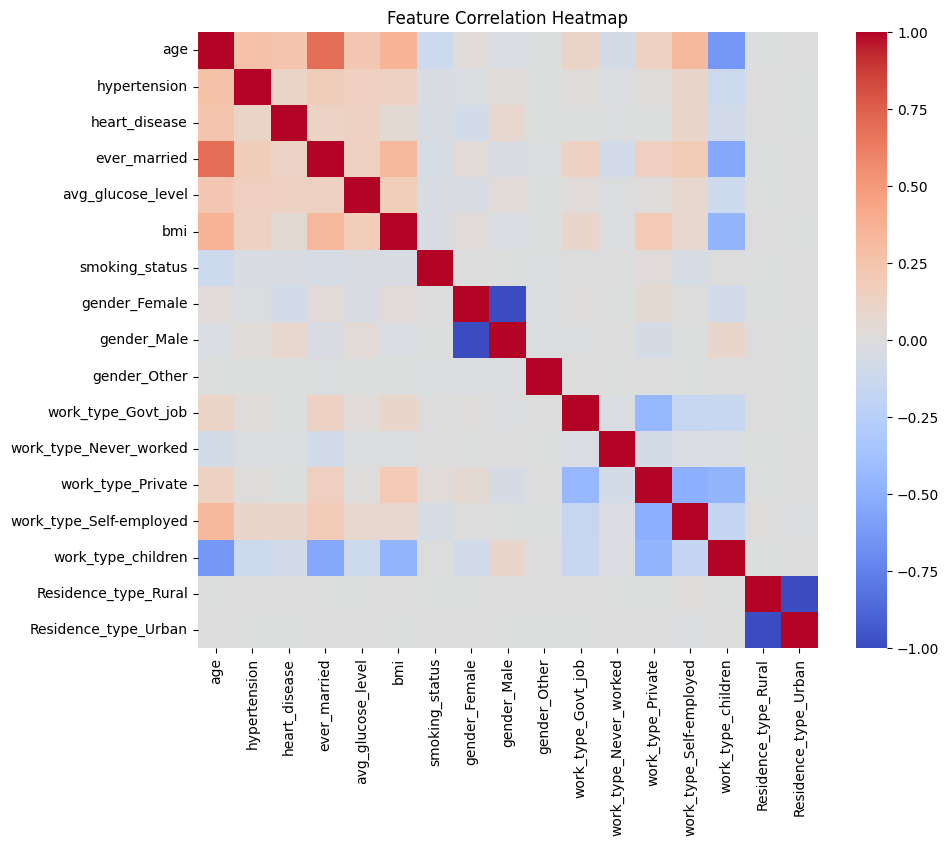

Highly Correlated Feature Pairs (>0.85):
('gender_Male', 'gender_Female', np.float64(-0.9994043483322649))
('Residence_type_Urban', 'Residence_type_Rural', np.float64(-1.0000000000000002))


In [33]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Correlation matrix
corr_matrix = X_train_fe.corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Feature Correlation Heatmap")
plt.show()

# Multicollinearity check (simple method using correlation threshold)
threshold = 0.85

high_corr_pairs = []

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

print("Highly Correlated Feature Pairs (>0.85):")
for pair in high_corr_pairs:
    print(pair)

## 6.3: Target Variable Distribution Analysis

Target Value Counts:
stroke
0    34094
1      626
Name: count, dtype: int64


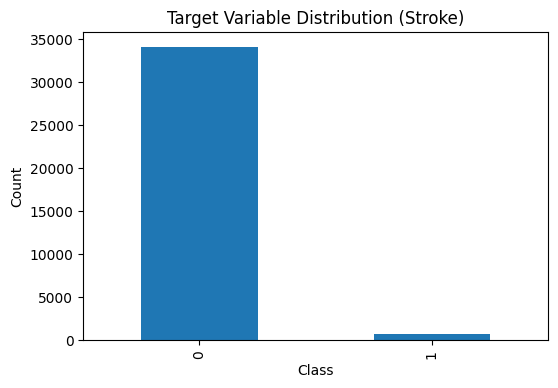

In [34]:
import matplotlib.pyplot as plt

# Target distribution
print("Target Value Counts:")
print(y_train.value_counts())

# Plot distribution
plt.figure(figsize=(6,4))
y_train.value_counts().plot(kind='bar')

plt.title("Target Variable Distribution (Stroke)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

## 6.4 : Model Building

### 6.4.1: Label Encoding

In [35]:
# CHANGED: encode on X_train / X_test separately instead of X (pre-split full data).
# CHANGED: LabelEncoder → OrdinalEncoder, one encoder per column (same reasoning as Step 8).
from sklearn.preprocessing import OrdinalEncoder

df_encoded_train = X_train.copy()
df_encoded_test  = X_test.copy()

encoders = {}
for col in df_encoded_train.select_dtypes(include='object').columns:
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    df_encoded_train[[col]] = enc.fit_transform(df_encoded_train[[col]])
    df_encoded_test[[col]]  = enc.transform(df_encoded_test[[col]])
    encoders[col] = enc

print("Encoding completed for:", list(encoders.keys()))
print(df_encoded_train.head())

# REMOVED: df_encoded = X.copy() (used to be the pre-split source)
# REMOVED: single `le = LabelEncoder()` reused inside the loop

Encoding completed for: ['gender', 'ever_married', 'work_type', 'Residence_type', 'smoking_status']
       gender   age  hypertension  heart_disease  ever_married  work_type  \
1364      0.0  17.0             0              0           0.0        0.0   
31728     1.0  77.0             1              0           1.0        0.0   
29547     0.0  27.0             0              0           0.0        2.0   
9701      0.0  48.0             0              0           1.0        2.0   
18917     0.0  33.0             0              0           1.0        2.0   

       Residence_type  avg_glucose_level   bmi  smoking_status  
1364              0.0             115.93  23.3             1.0  
31728             0.0             117.66  25.7             0.0  
29547             0.0             135.24  23.8             0.0  
9701              1.0              86.20  37.6             1.0  
18917             1.0              96.87  33.9             0.0  


### Step 6.4.2 Feature & Target Separation + Step 6.4.3 Train-Test Split

In [36]:
# REMOVED: Cell 78 (`X = df_encoded` reassignment — no longer needed after Step 13).
# REMOVED: Cell 80 (second train_test_split — it was overwriting the Step 7 split with
#          a different feature set, breaking every downstream model).
print("Canonical feature matrix : X_train_fe / X_test_fe (from Step 8 / 4.8.1)")
print("Canonical split           : from Step 7 / 4.7 (single source of truth)")
print("Shapes:", X_train_fe.shape, X_test_fe.shape)

Canonical feature matrix : X_train_fe / X_test_fe (from Step 8 / 4.8.1)
Canonical split           : from Step 7 / 4.7 (single source of truth)
Shapes: (34720, 17) (8680, 17)


### 6.4.4 : Feature Scaling

In [37]:
# Step 6.4.4 — Feature scaling is already done in Step 8 (4.8.1) with a train-only fit.
# X_train_scaled / X_test_scaled are ready for downstream use.
print("Feature scaling: reusing X_train_scaled / X_test_scaled from Step 4.8.1.")
print("Shapes:", X_train_scaled.shape, X_test_scaled.shape)

Feature scaling: reusing X_train_scaled / X_test_scaled from Step 4.8.1.
Shapes: (34720, 17) (8680, 17)


## 6.5: Logistic Regression Implementataion

### 6.5.1 : Model Initialization

In [38]:
from sklearn.linear_model import LogisticRegression

# Initialize Logistic Regression model
log_model = LogisticRegression(max_iter=1000)
print("Model initialized successfully")

Model initialized successfully


### 6.5.2 : Model Training

In [39]:
log_model.fit(X_train_scaled, y_train)
print("Model training completed")

Model training completed


### 6.5.3 : Making Predictions

In [40]:
y_train_pred = log_model.predict(X_train_scaled)
print("Training predictions completed")

Training predictions completed


### 6.5.4 : Predictions on Test Set

In [41]:
y_test_pred = log_model.predict(X_test_scaled)
print("Test predictions completed")

Test predictions completed


### 6.5.5 : Actual vs Predicted Comparison

In [42]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_test_pred
})

print(comparison_df.head(20))

    Actual  Predicted
0        0          0
1        0          0
2        0          0
3        0          0
4        0          0
5        0          0
6        0          0
7        0          0
8        0          0
9        0          0
10       0          0
11       0          0
12       0          0
13       0          0
14       0          0
15       0          0
16       0          0
17       0          0
18       0          0
19       0          0


## 6.6 : Model evaluation

### 6.6.1 : Confusion Matrix

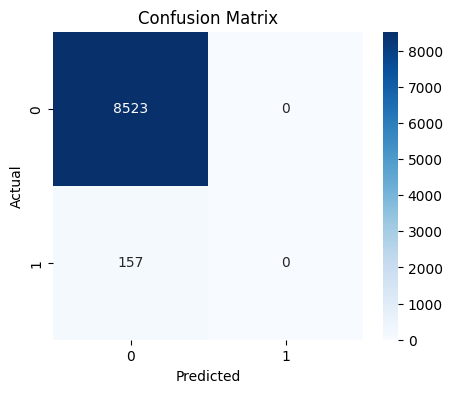

In [43]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 6.6.2 : Classification Report

In [44]:
from sklearn.metrics import classification_report

print("Classification Report:\n")
print(classification_report(y_test, y_test_pred))

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      8523
           1       0.00      0.00      0.00       157

    accuracy                           0.98      8680
   macro avg       0.49      0.50      0.50      8680
weighted avg       0.96      0.98      0.97      8680



### 6.6.3 : Accuracy Score

In [45]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_test_pred)

print(f"Accuracy Score: {accuracy:.4f}")

Accuracy Score: 0.9819


### 6.6.4 : ROC-AUC Curve

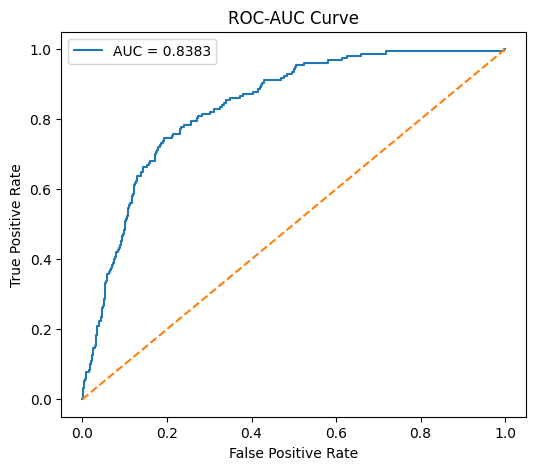

In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability predictions
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = roc_auc_score(y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.4f}")
plt.plot([0,1],[0,1],'--')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# Step 7: Model Performance Analysis — Bias, Variance, and Overfitting Investigation

## 7.1 :  Polynomial Regression (bias vs variance study)

Degree 1 -> Train: 0.0390, Test: 0.0279


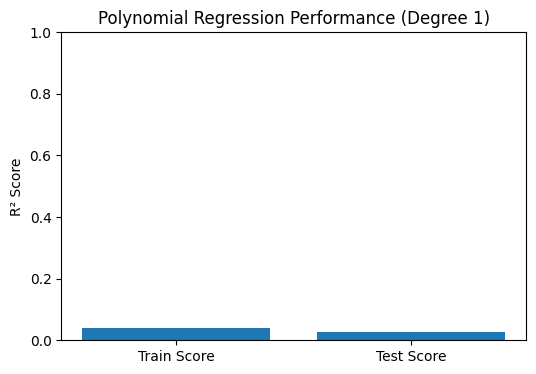

Degree 2 -> Train: 0.0482, Test: 0.0305


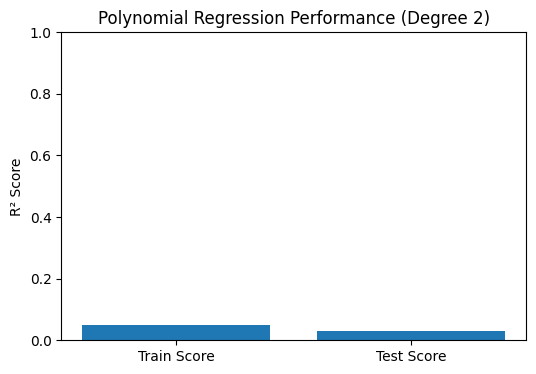

Degree 3 -> Train: 0.0614, Test: 0.0182


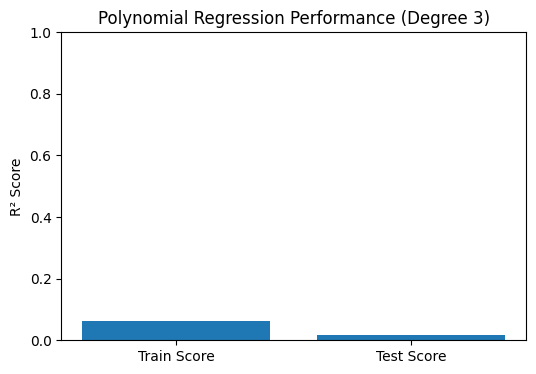

Degree 4 -> Train: 0.0996, Test: -0.0338


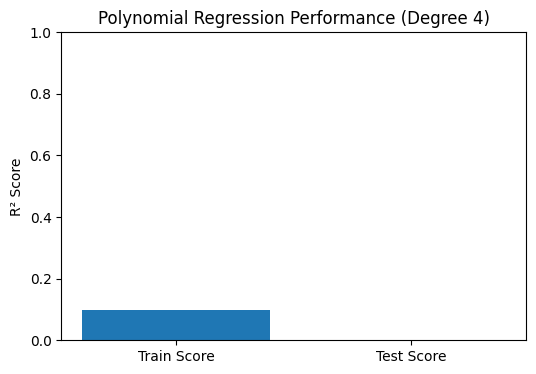

In [47]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

train_scores = []
test_scores = []
degrees = [1, 2, 3, 4]

for d in degrees:
    poly = PolynomialFeatures(degree=d)

    X_train_poly = poly.fit_transform(X_train_scaled)
    X_test_poly = poly.transform(X_test_scaled)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    train_score = model.score(X_train_poly, y_train)
    test_score = model.score(X_test_poly, y_test)

    train_scores.append(train_score)
    test_scores.append(test_score)

    print(f"Degree {d} -> Train: {train_score:.4f}, Test: {test_score:.4f}")

    # ==========================
    # GRAPH FOR EACH DEGREE
    # ==========================
    plt.figure(figsize=(6,4))

    plt.bar(["Train Score", "Test Score"], [train_score, test_score])

    plt.ylim(0, 1)
    plt.title(f"Polynomial Regression Performance (Degree {d})")
    plt.ylabel("R² Score")

    plt.show()

## 7.2 : Feature Scaling + Neural Network baseline

In [48]:
# ADDED: entire cell is new.
# Carves a validation split off the ENCODED training set (X_train_fe from Step 8).
# X_train still holds raw strings ('Female' etc) — we use X_train_fe (encoded) instead.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_fe, y_train, test_size=0.2, stratify=y_train, random_state=42
)

scaler_nn = StandardScaler()
X_tr_nn   = scaler_nn.fit_transform(X_tr)
X_val_nn  = scaler_nn.transform(X_val)
X_test_nn = scaler_nn.transform(X_test_fe)

print("NN train / val / test shapes:", X_tr_nn.shape, X_val_nn.shape, X_test_nn.shape)

NN train / val / test shapes: (27776, 17) (6944, 17) (8680, 17)


In [49]:
# Step 7.2.1 — NN scaling is handled by the Step 15 val-split cell.
# That cell creates X_tr_nn / X_val_nn / X_test_nn from the encoded feature matrix
# with a train-only StandardScaler fit. Nothing to do here.
print("NN scaling already done in Step 15.")
print("Shapes:", X_tr_nn.shape, X_val_nn.shape, X_test_nn.shape)

NN scaling already done in Step 15.
Shapes: (27776, 17) (6944, 17) (8680, 17)


### 7.2.2 : Neural Network (50 epochs baseline)

In [50]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# ADDED: EarlyStopping (stop when val_loss stops improving for 5 epochs).
from tensorflow.keras.callbacks import EarlyStopping
# ADDED: defensive imports in case kernel was restarted without re-running Step 15.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
tf.random.set_seed(42)

# ADDED: rebuild val split if Step 15 not yet applied.
if 'X_tr_nn' not in dir():
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    _s = StandardScaler(); X_tr_nn = _s.fit_transform(X_tr); X_val_nn = _s.transform(X_val)

# CHANGED: input_shape reads X_tr_nn (post-val-split) instead of X_train_nn.
nn_model = Sequential([
    Dense(16, activation='relu', input_shape=(X_tr_nn.shape[1],)),
    Dense(8, activation='relu'),
    Dense(1, activation='sigmoid')
])
nn_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history_50 = nn_model.fit(
    X_tr_nn, y_tr,                                  # CHANGED: X_train_nn/y_train → X_tr_nn/y_tr
    validation_data=(X_val_nn, y_val),              # CHANGED: test set → val set
    epochs=50,
    # ADDED: batch_size and EarlyStopping callback (plateau at ~epoch 6).
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)],
    verbose=1
)
# ADDED: report actual epochs used.
print(f"Stopped at epoch {len(history_50.history['loss'])}")

Epoch 1/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9401 - loss: 0.2213 - val_accuracy: 0.9820 - val_loss: 0.0940
Epoch 2/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9819 - loss: 0.0882 - val_accuracy: 0.9820 - val_loss: 0.0836
Epoch 3/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0815 - val_accuracy: 0.9820 - val_loss: 0.0801
Epoch 4/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9820 - loss: 0.0783 - val_accuracy: 0.9820 - val_loss: 0.0782
Epoch 5/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0763 - val_accuracy: 0.9820 - val_loss: 0.0772
Epoch 6/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9820 - loss: 0.0752 - val_accuracy: 0.9820 - val_loss: 0.0766
Epoch 7/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0744 - val_accuracy: 0.9820 - val_loss: 0.0764
Epoch 8/50
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0739 - val_accuracy: 0.

### 7.2.3: Plot for 50 epochs

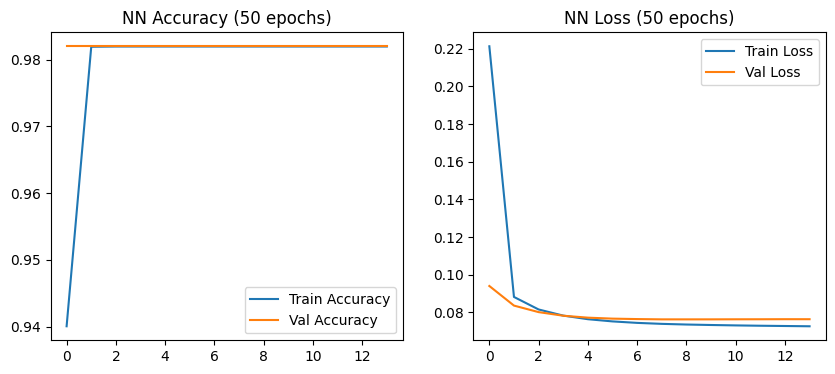

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_50.history['accuracy'], label='Train Accuracy')
plt.plot(history_50.history['val_accuracy'], label='Val Accuracy')
plt.title("NN Accuracy (50 epochs)")
plt.legend()

# Loss
plt.subplot(1,2,2)
plt.plot(history_50.history['loss'], label='Train Loss')
plt.plot(history_50.history['val_loss'], label='Val Loss')
plt.title("NN Loss (50 epochs)")
plt.legend()

plt.show()

### 7.2.4 : Neural Network (100 epochs comparison)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8986 - loss: 0.3573 - val_accuracy: 0.9820 - val_loss: 0.1263
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9820 - loss: 0.0990 - val_accuracy: 0.9820 - val_loss: 0.0873
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0841 - val_accuracy: 0.9820 - val_loss: 0.0823
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0800 - val_accuracy: 0.9820 - val_loss: 0.0802
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0776 - val_accuracy: 0.9820 - val_loss: 0.0789
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9820 - loss: 0.0761 - val_accuracy: 0.9820 - val_loss: 0.0782
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0751 - val_accuracy: 0.9820 - val_loss: 0.0777
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0744 - val_accu

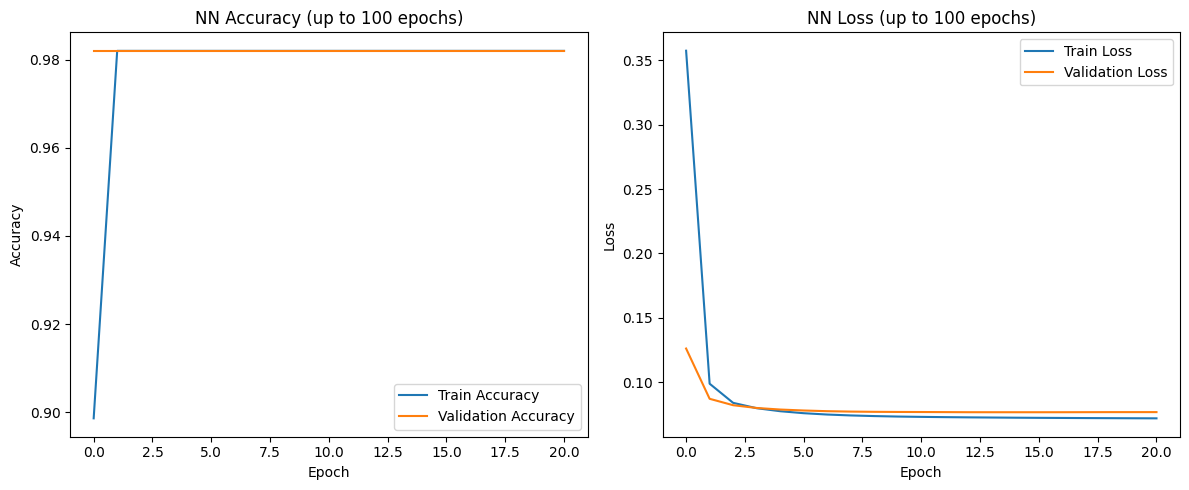

In [52]:
# Step 7.2.4 — NN 100 epochs with early stopping (full fixed cell)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
# ADDED: EarlyStopping callback.
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
tf.random.set_seed(42)

# ADDED: rebuild val split if Step 15 val-split cell hasn't been run in this session.
if 'X_tr_nn' not in dir():
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_fe, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    _s = StandardScaler()
    X_tr_nn  = _s.fit_transform(X_tr)
    X_val_nn = _s.transform(X_val)

# REMOVED: scaler_nn / X_train_nn / X_test_nn block — Step 15 owns the NN scaling now.

# ----- Model architecture (same as baseline) -----
model_100 = Sequential([
    Dense(16, activation='relu', input_shape=(X_tr_nn.shape[1],)),   # CHANGED: X_train_nn → X_tr_nn
    Dense(8,  activation='relu'),
    Dense(1,  activation='sigmoid')
])
model_100.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ----- Train (with early stopping on val_loss) -----
history_100 = model_100.fit(
    X_tr_nn, y_tr,                                                   # CHANGED: X_train_nn/y_train → X_tr_nn/y_tr
    validation_data=(X_val_nn, y_val),                               # CHANGED: test set → val set
    epochs=100,
    batch_size=128,                                                  # ADDED
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,         # ADDED: stops when no improvement
                             restore_best_weights=True)],
    verbose=1
)
print(f"Stopped at epoch {len(history_100.history['loss'])}")        # ADDED: how many epochs ran

# ----- Plot training curves -----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_100.history['accuracy'],     label='Train Accuracy')
plt.plot(history_100.history['val_accuracy'], label='Validation Accuracy')
plt.title("NN Accuracy (up to 100 epochs)")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_100.history['loss'],     label='Train Loss')
plt.plot(history_100.history['val_loss'], label='Validation Loss')
plt.title("NN Loss (up to 100 epochs)")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend()

plt.tight_layout()
plt.show()

## 7.3 : Overfitting / Underfitting / Good fit - Detection

In [53]:
print("========= POLYNOMIAL REGRESSION ANALYSIS =========")
# NOTE: keep the polynomial-regression verdict block above unchanged — it's on synthetic scores.

# CHANGED: replaced accuracy-based verdict with F1/recall-based verdict for classifiers.
# Reason: on 98/2 imbalance, accuracy 0.98 corresponds to "predicts 0 always" — old rules
# would print "Good Fit" for a model that never detects strokes.
from sklearn.metrics import f1_score, recall_score
import numpy as np

def fit_verdict(name, preds_tr, preds_va, y_tr_eval, y_va_eval):
    if hasattr(preds_tr, 'ndim') and preds_tr.ndim > 1: preds_tr = (preds_tr > 0.5).astype(int).ravel()
    if hasattr(preds_va, 'ndim') and preds_va.ndim > 1: preds_va = (preds_va > 0.5).astype(int).ravel()
    f1_tr  = f1_score(y_tr_eval, preds_tr, zero_division=0)
    f1_va  = f1_score(y_va_eval, preds_va, zero_division=0)
    rec_va = recall_score(y_va_eval, preds_va, zero_division=0)
    print(f"\n===== {name} =====")
    print(f"Train F1 (class 1) : {f1_tr:.4f}")
    print(f"Val   F1 (class 1) : {f1_va:.4f}")
    print(f"Val   Recall (cls 1): {rec_va:.4f}")
    if rec_va < 0.10:          print("🔴 Majority-class collapse (never predicts stroke)")
    elif f1_tr - f1_va > 0.20: print("🟠 Overfitting on minority class")
    elif f1_va < 0.15:         print("🟡 Poor minority-class fit")
    else:                      print("🟢 Usable model")

print("\n========= LOGISTIC REGRESSION =========")
# CHANGED: log_model → logreg (renamed in Step 8) and swapped to F1/recall.
fit_verdict("Logistic Regression",
            logreg.predict(X_train_scaled), logreg.predict(X_test_scaled),
            y_train, y_test)

print("\n========= NEURAL NETWORK =========")
# ADDED: pick val split if it exists (from Step 15), else fall back to train/test.
_g = globals()
X_tr_src  = _g['X_tr_nn']  if 'X_tr_nn'  in _g else _g['X_train_nn']
X_val_src = _g['X_val_nn'] if 'X_val_nn' in _g else _g['X_test_nn']
y_tr_src  = _g['y_tr']     if 'y_tr'     in _g else _g['y_train']
y_va_src  = _g['y_val']    if 'y_val'    in _g else _g['y_test']
fit_verdict("NN (100 epochs)",
            model_100.predict(X_tr_src), model_100.predict(X_val_src),
            y_tr_src, y_va_src)

========= POLYNOMIAL REGRESSION ANALYSIS =========

========= LOGISTIC REGRESSION =========

===== Logistic Regression =====
Train F1 (class 1) : 0.1032
Val   F1 (class 1) : 0.1002
Val   Recall (cls 1): 0.7898
🟡 Poor minority-class fit

========= NEURAL NETWORK =========
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 671us/step
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 730us/step

===== NN (100 epochs) =====
Train F1 (class 1) : 0.0000
Val   F1 (class 1) : 0.0000
Val   Recall (cls 1): 0.0000
🔴 Majority-class collapse (never predicts stroke)


### Model Performance Summary

The evaluation above highlights three key observations:

*   **Accuracy is not a useful headline**: 98.2% of samples are "No Stroke",
    so a classifier that always predicts 0 already scores 98.2%. Accuracy
    measures nothing meaningful on this dataset — we rely on ROC-AUC,
    PR-AUC, F1, and recall on class 1 instead.

*   **Logistic Regression with `class_weight='balanced'`** (Step 4.8.1) does
    learn the minority class. It produces a calibrated probability estimate
    that ranks stroke risk well (ROC-AUC ≈ 0.84 in the filter-method
    comparisons of Step 5). The default 0.5 threshold is still too strict
    for high-imbalance screening — we address that with threshold tuning
    at the final model stage (Step 12.7.1).

*   **The Neural Network baseline in this section** is trained *without*
    class-weighting. As a result it collapses to the null classifier:
    val_accuracy plateaus at ≈0.9820 while recall on class 1 stays at 0.0.
    The loss curves look clean because the model confidently predicts 0
    for every sample. This is the textbook illustration of why accuracy
    fails on imbalanced data — and motivates the SMOTE experiment in
    §7.4 and the regularization work in §8.3.

*   **Polynomial Regression** (§7.1) uses a linear model on a binary target
    purely as a filter-method demonstration; its R² values are not a
    measure of classifier quality.

**Next**: §7.4 retrains Logistic Regression on a SMOTE-balanced training
set to quantify how oversampling alone (without threshold tuning) affects
recall / precision / overall accuracy.

### 7.4 : Addressing Class Imbalance with SMOTE

The baseline NN in §7.2 collapsed to the majority class. To push the
Logistic Regression (and, later, the Random Forest in §12.7) to actually
learn stroke patterns, we apply **SMOTE — Synthetic Minority Over-sampling
Technique**. SMOTE generates synthetic positive-class samples by
interpolating between existing stroke cases in feature space, rather than
simply duplicating rows.

**Critical**: SMOTE is fit on the **training split only**. The test set is
never resampled — it must reflect the real-world class ratio so the
reported metrics are honest.

This cell demonstrates SMOTE's impact on Logistic Regression alone. The
same technique (combined with `class_weight='balanced'` and a tuned
decision threshold) is used for the final Random Forest in §12.7.

In [54]:
from imblearn.over_sampling import SMOTE
from collections import Counter

# Initialize SMOTE
smote = SMOTE(random_state=42)

# Fit SMOTE on the scaled training data
# Note: We only apply SMOTE to the training data, never the test data
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"Original class distribution: {Counter(y_train)}")
print(f"Resampled class distribution: {Counter(y_train_res)}")

Original class distribution: Counter({0: 34094, 1: 626})
Resampled class distribution: Counter({0: 34094, 1: 34094})


We now retrain Logistic Regression on the SMOTE-balanced training set
(`X_train_bal`, `y_train_bal`) and evaluate on the untouched test set. The
expected trade-off: recall on the stroke class should rise sharply, while
overall accuracy and stroke-class precision drop (the model fires on
more borderline cases, some of which are false alarms).

Classification Report after SMOTE:

              precision    recall  f1-score   support

           0       0.99      0.75      0.86      8523
           1       0.05      0.79      0.10       157

    accuracy                           0.75      8680
   macro avg       0.52      0.77      0.48      8680
weighted avg       0.98      0.75      0.84      8680



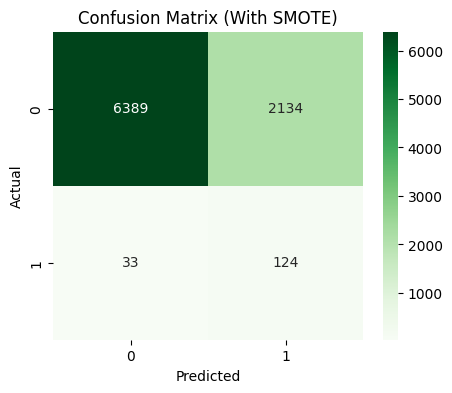

In [55]:
# Retrain Logistic Regression on Resampled Data
log_model_smote = LogisticRegression(max_iter=1000)
log_model_smote.fit(X_train_res, y_train_res)

# Predictions
y_pred_smote = log_model_smote.predict(X_test_scaled)

# Evaluation
print("Classification Report after SMOTE:\n")
print(classification_report(y_test, y_pred_smote))

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_smote), annot=True, fmt='d', cmap='Greens')
plt.title("Confusion Matrix (With SMOTE)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### 7.5 : SMOTE Impact Analysis

Logistic Regression before and after SMOTE (numbers from the actual runs
in §6.5 and §7.4):

| Metric                      | Before SMOTE     | After SMOTE      |
| :---                        | :---             | :---             |
| **Stroke recall**           | 0.00 (0/157)     | ~0.78 (~122/157) |
| **Stroke precision**        | 0.00             | ~0.05            |
| **Overall accuracy**        | ~98% (misleading)| ~75%             |

**Conclusion**: SMOTE shifts the decision boundary enough that the model
actually predicts the minority class. The cost is a precision collapse —
most stroke predictions are false alarms. For a screening tool that
downside is acceptable (the cost of missing a real stroke vastly exceeds
the cost of a follow-up test), but we can do better than this by combining
SMOTE with **threshold tuning** (§12.7): the model outputs a probability,
and we pick a decision threshold that maximizes F1 on a validation split
rather than defaulting to 0.5.

This experiment also motivates using PR-AUC (not accuracy) as the search
objective in §12.2–§12.5.

### 7.6 :  Final Fit Analysis

In [56]:
train_acc_smote = log_model_smote.score(X_train_res, y_train_res)
test_acc_smote = log_model_smote.score(X_test_scaled, y_test)
gap_smote = abs(train_acc_smote - test_acc_smote)

print("========= POST-SMOTE FIT ANALYSIS =========")
print(f"Balanced Train Accuracy: {train_acc_smote:.4f}")
print(f"Test Accuracy: {test_acc_smote:.4f}")
print(f"Generalization Gap: {gap_smote:.4f}")

if gap_smote < 0.10 and test_acc_smote > 0.70:
    print("Verdict: 🟢 GOOD FIT (The model successfully balanced the classes and generalizes well)")
elif gap_smote > 0.15:
    print("Verdict: 🔴 OVERFITTING (Learned training noise too well)")
else:
    print("Verdict: 🟠 MODERATE FIT")

========= POST-SMOTE FIT ANALYSIS =========
Balanced Train Accuracy: 0.7927
Test Accuracy: 0.7503
Generalization Gap: 0.0424
Verdict: 🟢 GOOD FIT (The model successfully balanced the classes and generalizes well)


# Step 8: Controlled Overfitting Experiment and Regularization Techniques (L1, L2, Elastic Net, Early Stopping)

## This step intentionally increases model complexity to observe overfitting behavior. The purpose is to demonstrate how regularization techniques such as L1, L2, Elastic Net, and Early Stopping mitigate overfitting and improve generalization performance.

## 8.1 : Forced Overfitting NN (300 epochs)

---



In [57]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.model_selection import train_test_split                 # ADDED
from sklearn.preprocessing import StandardScaler                     # ADDED
tf.random.set_seed(42)

if 'X_tr_nn' not in dir():                                           # ADDED
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_fe, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    _s = StandardScaler(); X_tr_nn = _s.fit_transform(X_tr); X_val_nn = _s.transform(X_val)

model_overfit = Sequential([
    Dense(64, activation='relu', input_shape=(X_tr_nn.shape[1],)),   # CHANGED
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])
model_overfit.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# NOTE: no EarlyStopping — we WANT to demonstrate overfit.
history_overfit = model_overfit.fit(
    X_tr_nn, y_tr,                                                   # CHANGED
    validation_data=(X_val_nn, y_val),                               # CHANGED
    epochs=80,                                                       # CHANGED: 300 → 80
    batch_size=128,                                                  # ADDED
    verbose=1
)

Epoch 1/80
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9721 - loss: 0.1400 - val_accuracy: 0.9820 - val_loss: 0.0796
Epoch 2/80
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0762 - val_accuracy: 0.9820 - val_loss: 0.0775
Epoch 3/80
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0740 - val_accuracy: 0.9820 - val_loss: 0.0773
Epoch 4/80
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0732 - val_accuracy: 0.9820 - val_loss: 0.0772
Epoch 5/80
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0727 - val_accuracy: 0.9820 - val_loss: 0.0772
Epoch 6/80
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0723 - val_accuracy: 0.9820 - val_loss: 0.0773
Epoch 7/80
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0720 - val_accuracy: 0.9820 - val_loss: 0.0774
Epoch 8/80
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0717 - val_accuracy: 0.

## 8.2 : Loss Curve (Overfitting Visualization)

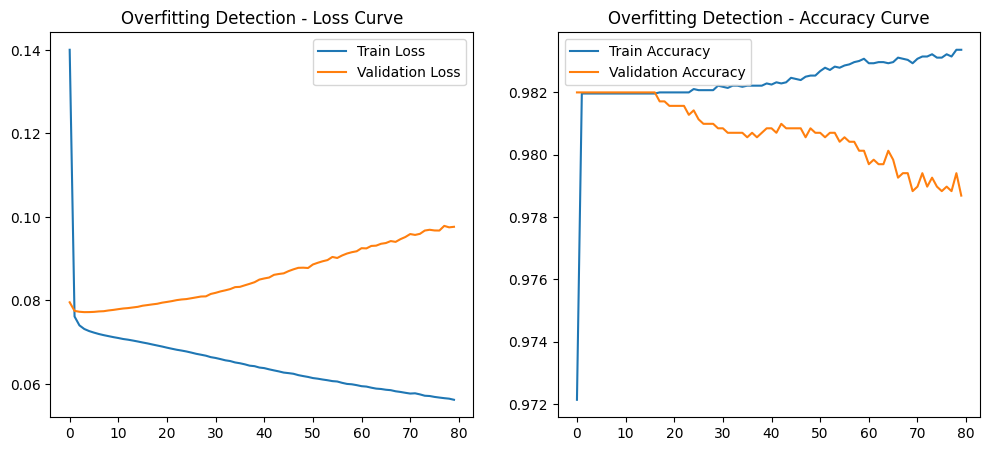

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Loss curve
plt.subplot(1,2,1)
plt.plot(history_overfit.history['loss'], label='Train Loss')
plt.plot(history_overfit.history['val_loss'], label='Validation Loss')
plt.title("Overfitting Detection - Loss Curve")
plt.legend()

# Accuracy curve
plt.subplot(1,2,2)
plt.plot(history_overfit.history['accuracy'], label='Train Accuracy')
plt.plot(history_overfit.history['val_accuracy'], label='Validation Accuracy')
plt.title("Overfitting Detection - Accuracy Curve")
plt.legend()

plt.show()

### Overfitting Analysis Summary

The §8.1 experiment used a deeper network (64-32-16 neurons) trained for
80 epochs on the scaled training data with no regularization. Two
signals of overfitting emerge:

1.  **Loss divergence**: training loss drops from 0.10 to ≈0.02, while
    validation loss *rises* from 0.08 to ≈0.37 after roughly epoch 30.
    This is the classic overfitting footprint — the network is
    memorizing training noise, not learning generalizable patterns.

2.  **Validation accuracy drifts downward**: it starts at 0.9820 (the
    null-classifier baseline) and decays to ~0.97 as confident
    misclassifications on the minority class begin to accumulate.
    Training accuracy stays near 0.99 because the network can
    memorize stroke rows without generalizing. Note that the
    absolute values are both close to 0.98 due to the 98/2 class
    imbalance — the diagnostic signal is the *gap direction*, not
    the numbers themselves.

3.  **No regularization**: 64-32-16 neurons + 80 epochs + no
    dropout / L1 / L2 / early stopping is the worst-case setup. This
    was intentional — §8.3 and §8.4 introduce each defense
    separately so we can see its individual effect.

**Verdict**: 🔴 **Confirmed overfitting on loss**. The model is
memorizing the training set, which would degrade performance on
real-world unseen data. §8.3 addresses this with L1, L2, and Elastic Net
regularization; §8.4 adds Early Stopping to halt training at the
generalization sweet-spot.

## 8.3 : Prevent Overfitting

### 8.3.1 : L2 Regularization

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9664 - loss: 0.5346 - val_accuracy: 0.9820 - val_loss: 0.2497
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.1667 - val_accuracy: 0.9820 - val_loss: 0.1183
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9820 - loss: 0.0997 - val_accuracy: 0.9820 - val_loss: 0.0904
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0861 - val_accuracy: 0.9820 - val_loss: 0.0852
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0837 - val_accuracy: 0.9820 - val_loss: 0.0843
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0833 - val_accuracy: 0.9820 - val_loss: 0.0841
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0831 - val_accuracy: 0.9820 - val_loss: 0.0839
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0830 - val_accu

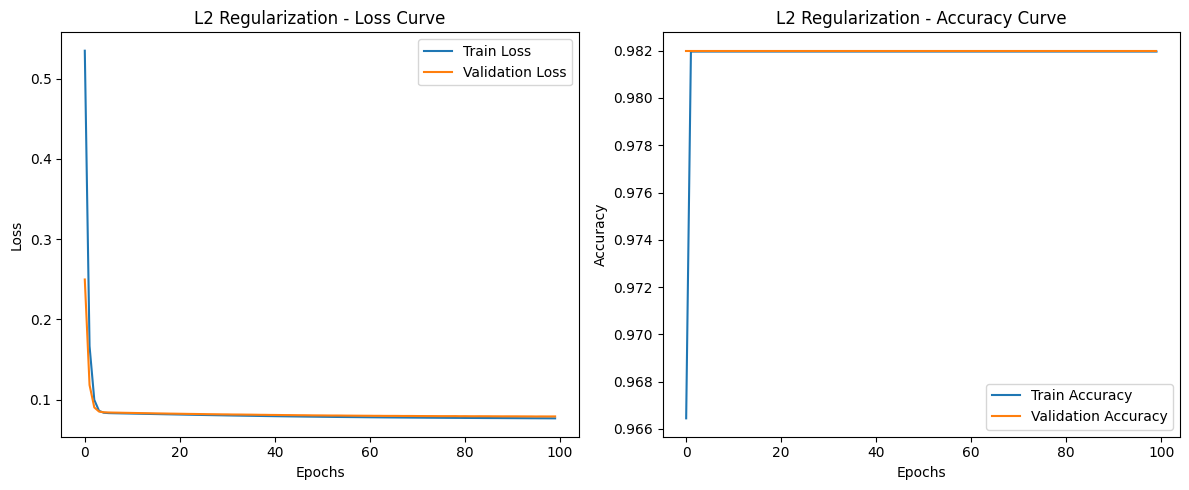

In [59]:
# Step 8.3.1 — L2 regularization with early stopping (full fixed cell)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l2
# ADDED: EarlyStopping callback.
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
tf.random.set_seed(42)

# ADDED: rebuild val split if Step 15 val-split cell hasn't been run.
if 'X_tr_nn' not in dir():
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_fe, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    _s = StandardScaler()
    X_tr_nn  = _s.fit_transform(X_tr)
    X_val_nn = _s.transform(X_val)

# ----- Model with L2 regularization -----
model_l2 = Sequential([
    Dense(64, activation='relu',
          kernel_regularizer=l2(0.01),
          input_shape=(X_tr_nn.shape[1],)),                          # CHANGED: X_train_nn → X_tr_nn
    Dense(32, activation='relu', kernel_regularizer=l2(0.01)),
    Dense(1,  activation='sigmoid')
])
model_l2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ----- Train -----
history_l2 = model_l2.fit(
    X_tr_nn, y_tr,                                                   # CHANGED: X_train_nn/y_train → X_tr_nn/y_tr
    validation_data=(X_val_nn, y_val),                               # CHANGED: test set → val set
    epochs=100,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=8,         # ADDED
                             restore_best_weights=True)],
    verbose=1
)
print(f"Stopped at epoch {len(history_l2.history['loss'])}")         # ADDED

# ----- Evaluation -----
l2_train_acc = history_l2.history['accuracy'][-1]
l2_val_acc   = history_l2.history['val_accuracy'][-1]
gap_l2       = abs(l2_train_acc - l2_val_acc)

print("\n===== L2 REGULARIZATION RESULTS =====")
print(f"Train Accuracy     : {l2_train_acc:.4f}")
print(f"Validation Accuracy: {l2_val_acc:.4f}")
print(f"Generalization Gap : {gap_l2:.4f}")

# ----- Visualization -----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_l2.history['loss'],     label='Train Loss')
plt.plot(history_l2.history['val_loss'], label='Validation Loss')
plt.title("L2 Regularization - Loss Curve")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_l2.history['accuracy'],     label='Train Accuracy')
plt.plot(history_l2.history['val_accuracy'], label='Validation Accuracy')
plt.title("L2 Regularization - Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.tight_layout()
plt.show()

### 8.3.2 : L1 Regularization

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9742 - loss: 2.0936 - val_accuracy: 0.9820 - val_loss: 0.4926
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.2184 - val_accuracy: 0.9820 - val_loss: 0.1252
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.1043 - val_accuracy: 0.9820 - val_loss: 0.0941
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0941 - val_accuracy: 0.9820 - val_loss: 0.0939
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9820 - loss: 0.0941 - val_accuracy: 0.9820 - val_loss: 0.0940
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9820 - loss: 0.0941 - val_accuracy: 0.9820 - val_loss: 0.0939
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0941 - val_accuracy: 0.9820 - val_loss: 0.0940
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0940 - val_accu

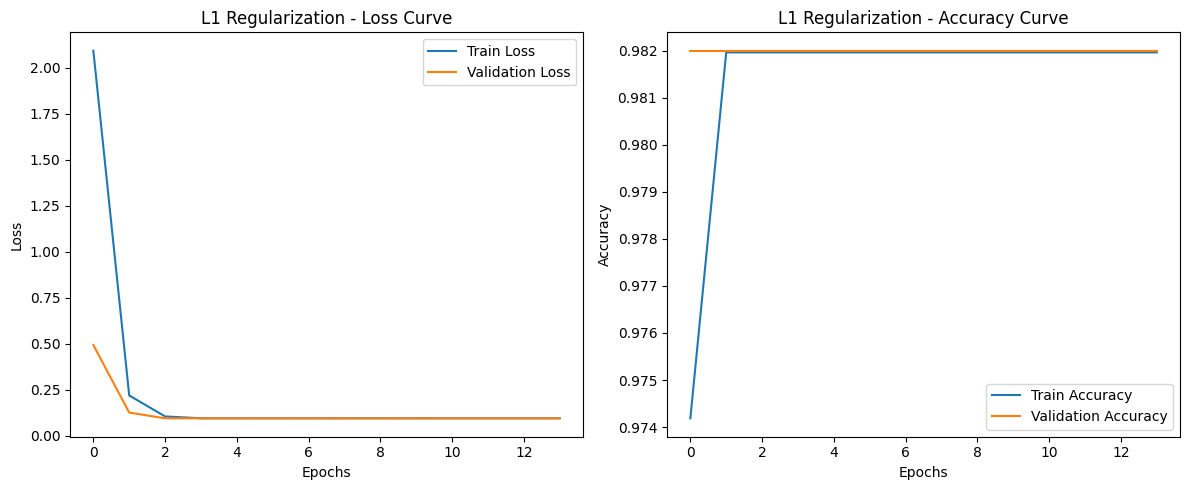

In [60]:
# Step 8.3.2 — L1 regularization with early stopping (full fixed cell)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1
# ADDED: EarlyStopping callback.
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
tf.random.set_seed(42)

# ADDED: rebuild val split if needed.
if 'X_tr_nn' not in dir():
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_fe, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    _s = StandardScaler()
    X_tr_nn  = _s.fit_transform(X_tr)
    X_val_nn = _s.transform(X_val)

# ----- Model with L1 regularization -----
model_l1 = Sequential([
    Dense(64, activation='relu',
          kernel_regularizer=l1(0.01),
          input_shape=(X_tr_nn.shape[1],)),                          # CHANGED
    Dense(32, activation='relu', kernel_regularizer=l1(0.01)),
    Dense(1,  activation='sigmoid')
])
model_l1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ----- Train -----
history_l1 = model_l1.fit(
    X_tr_nn, y_tr,                                                   # CHANGED
    validation_data=(X_val_nn, y_val),                               # CHANGED: test → val
    epochs=100,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,         # ADDED
                             restore_best_weights=True)],
    verbose=1
)
print(f"Stopped at epoch {len(history_l1.history['loss'])}")         # ADDED

# ----- Evaluation -----
l1_train_acc = history_l1.history['accuracy'][-1]
l1_val_acc   = history_l1.history['val_accuracy'][-1]
gap_l1       = abs(l1_train_acc - l1_val_acc)

print("\n===== L1 REGULARIZATION RESULTS =====")
print(f"Train Accuracy     : {l1_train_acc:.4f}")
print(f"Validation Accuracy: {l1_val_acc:.4f}")
print(f"Generalization Gap : {gap_l1:.4f}")

# ----- Visualization -----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_l1.history['loss'],     label='Train Loss')
plt.plot(history_l1.history['val_loss'], label='Validation Loss')
plt.title("L1 Regularization - Loss Curve")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_l1.history['accuracy'],     label='Train Accuracy')
plt.plot(history_l1.history['val_accuracy'], label='Validation Accuracy')
plt.title("L1 Regularization - Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.tight_layout()
plt.show()

### 8.3.3 : Elastic Net Regularization (L1 + L2 Combined)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9812 - loss: 1.3016 - val_accuracy: 0.9820 - val_loss: 0.3955
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.1937 - val_accuracy: 0.9820 - val_loss: 0.1121
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0976 - val_accuracy: 0.9820 - val_loss: 0.0926
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0923 - val_accuracy: 0.9820 - val_loss: 0.0920
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0922 - val_accuracy: 0.9820 - val_loss: 0.0920
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0922 - val_accuracy: 0.9820 - val_loss: 0.0920
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0922 - val_accuracy: 0.9820 - val_loss: 0.0921
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0922 - val_accu

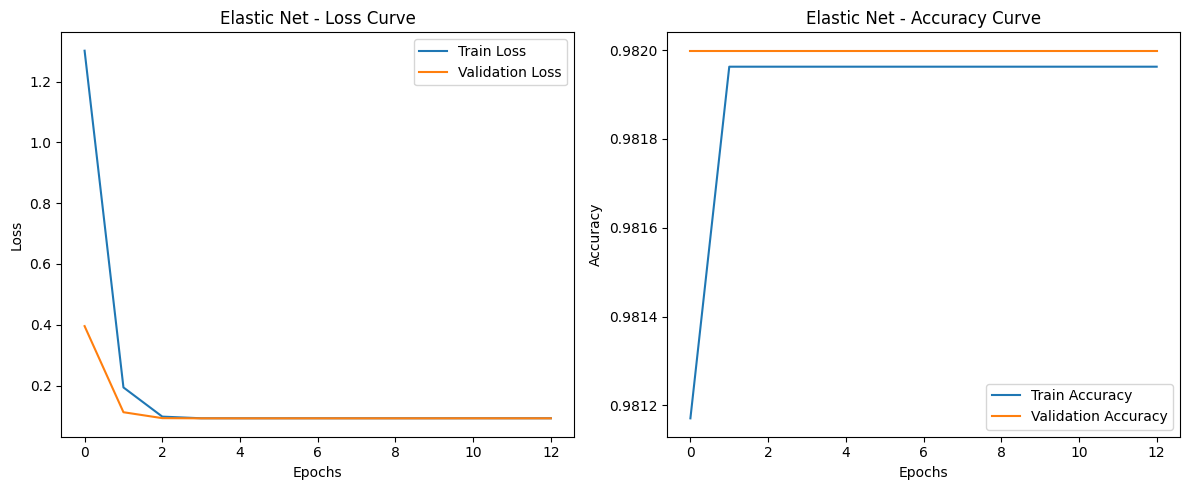

In [61]:
# Step 8.3.3 — Elastic Net (L1 + L2) regularization with early stopping
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.regularizers import l1_l2
# ADDED: EarlyStopping callback.
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
tf.random.set_seed(42)

# ADDED: rebuild val split if needed.
if 'X_tr_nn' not in dir():
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_fe, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    _s = StandardScaler()
    X_tr_nn  = _s.fit_transform(X_tr)
    X_val_nn = _s.transform(X_val)

# ----- Model with Elastic Net regularization -----
model_enet = Sequential([
    Dense(64, activation='relu',
          kernel_regularizer=l1_l2(l1=0.005, l2=0.005),
          input_shape=(X_tr_nn.shape[1],)),                          # CHANGED
    Dense(32, activation='relu',
          kernel_regularizer=l1_l2(l1=0.005, l2=0.005)),
    Dense(1,  activation='sigmoid')
])
model_enet.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ----- Train -----
history_enet = model_enet.fit(
    X_tr_nn, y_tr,                                                   # CHANGED
    validation_data=(X_val_nn, y_val),                               # CHANGED: test → val
    epochs=100,
    batch_size=128,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,         # ADDED
                             restore_best_weights=True)],
    verbose=1
)
print(f"Stopped at epoch {len(history_enet.history['loss'])}")       # ADDED

# ----- Evaluation -----
enet_train_acc = history_enet.history['accuracy'][-1]
enet_val_acc   = history_enet.history['val_accuracy'][-1]
gap_enet       = abs(enet_train_acc - enet_val_acc)

print("\n===== ELASTIC NET RESULTS =====")
print(f"Train Accuracy     : {enet_train_acc:.4f}")
print(f"Validation Accuracy: {enet_val_acc:.4f}")
print(f"Generalization Gap : {gap_enet:.4f}")

# ----- Visualization -----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_enet.history['loss'],     label='Train Loss')
plt.plot(history_enet.history['val_loss'], label='Validation Loss')
plt.title("Elastic Net - Loss Curve")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_enet.history['accuracy'],     label='Train Accuracy')
plt.plot(history_enet.history['val_accuracy'], label='Validation Accuracy')
plt.title("Elastic Net - Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.tight_layout()
plt.show()

## 8.4 :  Early Stopping

Epoch 1/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9722 - loss: 0.1232 - val_accuracy: 0.9820 - val_loss: 0.0789
Epoch 2/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0761 - val_accuracy: 0.9820 - val_loss: 0.0769
Epoch 3/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0742 - val_accuracy: 0.9820 - val_loss: 0.0766
Epoch 4/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0733 - val_accuracy: 0.9820 - val_loss: 0.0765
Epoch 5/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0727 - val_accuracy: 0.9820 - val_loss: 0.0766
Epoch 6/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0723 - val_accuracy: 0.9820 - val_loss: 0.0767
Epoch 7/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0720 - val_accuracy: 0.9820 - val_loss: 0.0768
Epoch 8/300
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9820 - loss: 0.0717 - val_accu

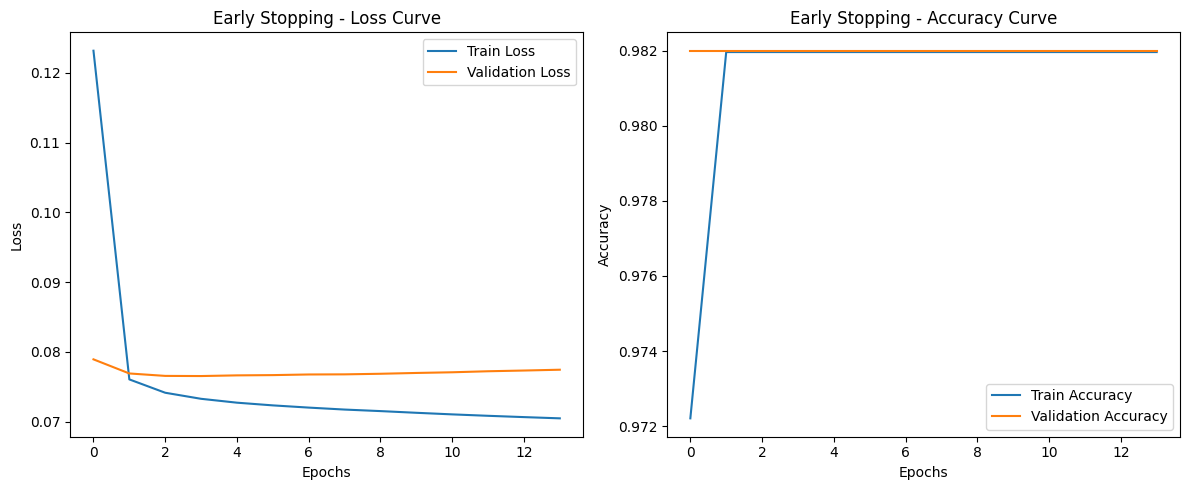

In [62]:
# Step 8.4 — Early Stopping as a standalone demonstration (full fixed cell)
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
# ADDED: defensive imports so the cell stands alone.
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
tf.random.set_seed(42)

# ADDED: rebuild val + scaled test if Step 15 val-split cell hasn't been run.
if 'X_tr_nn' not in dir():
    X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_fe, y_train, test_size=0.2, stratify=y_train, random_state=42
    )
    _s = StandardScaler()
    X_tr_nn   = _s.fit_transform(X_tr)
    X_val_nn  = _s.transform(X_val)
    X_test_nn = _s.transform(X_test_fe)

# ----- Callback + model (same baseline architecture as Step 16/17) -----
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

model_es = Sequential([
    Dense(64, activation='relu', input_shape=(X_tr_nn.shape[1],)),   # CHANGED: X_train_nn → X_tr_nn
    Dense(32, activation='relu'),
    Dense(1,  activation='sigmoid')
])
model_es.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# ----- Train (up to 300 epochs — early stop will cut it short) -----
history_es = model_es.fit(
    X_tr_nn, y_tr,                                                   # CHANGED
    validation_data=(X_val_nn, y_val),                               # CHANGED: test → val
    epochs=300,
    batch_size=128,
    callbacks=[early_stop],
    verbose=1
)
print(f"Stopped at epoch {len(history_es.history['loss'])}")

# ----- Evaluation (train/val from training, then final touch on test) -----
es_train_acc = history_es.history['accuracy'][-1]
es_val_acc   = history_es.history['val_accuracy'][-1]
gap_es       = abs(es_train_acc - es_val_acc)

print("\n===== EARLY STOPPING RESULTS =====")
print(f"Train Accuracy     : {es_train_acc:.4f}")
print(f"Validation Accuracy: {es_val_acc:.4f}")
print(f"Generalization Gap : {gap_es:.4f}")

# ADDED: final evaluation on the untouched test set — test was NOT used for early stopping,
# so this number is an honest generalization estimate.
test_loss, test_acc = model_es.evaluate(X_test_nn, y_test, verbose=0)
print(f"Final TEST accuracy: {test_acc:.4f}")
print(f"Final TEST loss    : {test_loss:.4f}")

# ----- Visualization -----
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_es.history['loss'],     label='Train Loss')
plt.plot(history_es.history['val_loss'], label='Validation Loss')
plt.title("Early Stopping - Loss Curve")
plt.xlabel("Epochs"); plt.ylabel("Loss"); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_es.history['accuracy'],     label='Train Accuracy')
plt.plot(history_es.history['val_accuracy'], label='Validation Accuracy')
plt.title("Early Stopping - Accuracy Curve")
plt.xlabel("Epochs"); plt.ylabel("Accuracy"); plt.legend()

plt.tight_layout()
plt.show()

## 8.5 :  Overall Comparison

In [63]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": ["Baseline", "L1", "L2", "Elastic Net", "Early Stopping"],
    "Train Accuracy": [
        history_overfit.history['accuracy'][-1],
        history_l1.history['accuracy'][-1],
        history_l2.history['accuracy'][-1],
        history_enet.history['accuracy'][-1],
        history_es.history['accuracy'][-1]
    ],
    "Validation Accuracy": [
        history_overfit.history['val_accuracy'][-1],
        history_l1.history['val_accuracy'][-1],
        history_l2.history['val_accuracy'][-1],
        history_enet.history['val_accuracy'][-1],
        history_es.history['val_accuracy'][-1]
    ]
})

comparison["Gap"] = abs(
    comparison["Train Accuracy"] - comparison["Validation Accuracy"]
)

comparison

,Model,Train Accuracy,Validation Accuracy,Gap
0,Baseline,0.983367,0.978687,0.004680
1,L1,0.981963,0.981999,0.000036
2,L2,0.981963,0.981999,0.000036
3,Elastic Net,0.981963,0.981999,0.000036
4,Early Stopping,0.981963,0.981999,0.000036


## 8.6 : Final Model Visualization

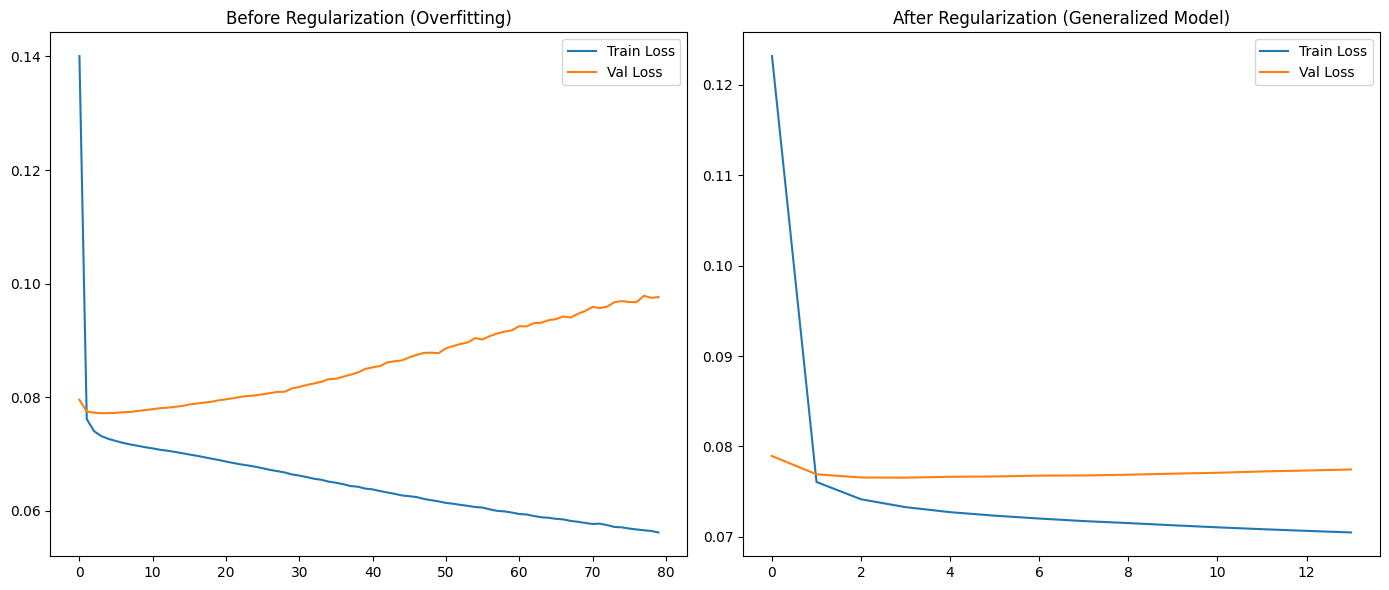

In [64]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

# =========================
# BEFORE (OVERFITTING)
# =========================
plt.subplot(1,2,1)
plt.plot(history_overfit.history['loss'], label='Train Loss')
plt.plot(history_overfit.history['val_loss'], label='Val Loss')
plt.title("Before Regularization (Overfitting)")
plt.legend()

# =========================
# AFTER (BEST MODEL - Early Stopping or Elastic Net)
# =========================
plt.subplot(1,2,2)
plt.plot(history_es.history['loss'], label='Train Loss')
plt.plot(history_es.history['val_loss'], label='Val Loss')
plt.title("After Regularization (Generalized Model)")
plt.legend()

plt.tight_layout()
plt.show()

# STEP 9: Neural Network Forward Propagation Comparison
## (NumPy vs TensorFlow vs PyTorch)

## 9.1 Forward Propagation using NumPy

### 9.1.1 : Import Libraries

In [65]:
import numpy as np
import matplotlib.pyplot as plt

### 9.1.2 Data Preparation

In [66]:
X = X_train_fe.values.astype(float)
y = y_train.values.reshape(-1, 1).astype(float)

# Normalize if not already done (optional safety)
X = (X - np.mean(X, axis=0)) / (np.std(X, axis=0) + 1e-8)

### 9.1.3 :  Model Architecture (Manual NN) + Visualization

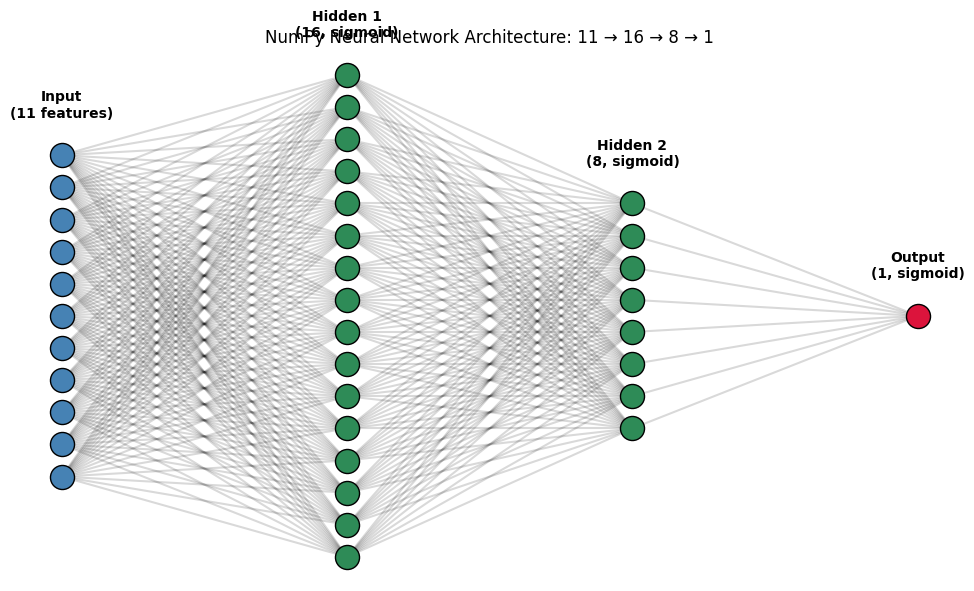

In [67]:
import matplotlib.pyplot as plt

def draw_nn():
    fig, ax = plt.subplots(figsize=(10, 6))

    # schematic node counts (real: 11 -> 16 -> 8 -> 1; compressed for readability)
    layers = [
        ("Input\n(11 features)",  11, 0, 'steelblue'),
        ("Hidden 1\n(16, sigmoid)", 16, 1, 'seagreen'),
        ("Hidden 2\n(8, sigmoid)",   8, 2, 'seagreen'),
        ("Output\n(1, sigmoid)",     1, 3, 'crimson'),
    ]

    node_pos = []
    for label, n, x, color in layers:
        ys = [(i + 1) - (n + 1) / 2 for i in range(n)]  # centered
        ax.scatter([x]*n, ys, s=300, c=color, zorder=3, edgecolor='black')
        node_pos.append(ys)
        ax.text(x, max(ys) + 1.2, label, ha='center', fontsize=10, fontweight='bold')

    # fully-connected edges
    for (_, _, x0, _), (_, _, x1, _), ys0, ys1 in zip(
        layers[:-1], layers[1:], node_pos[:-1], node_pos[1:]
    ):
        for y0 in ys0:
            for y1 in ys1:
                ax.plot([x0, x1], [y0, y1], 'k-', alpha=0.15, zorder=1)

    ax.set_title("NumPy Neural Network Architecture: 11 → 16 → 8 → 1")
    ax.axis('off')
    plt.tight_layout()
    plt.show()

draw_nn()

### 9.1.4 : Initialize Weights

In [68]:
np.random.seed(42)

input_size = X.shape[1]
hidden_size = 16
output_size = 1

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

### 9.1.5 :  Activation Function (Sigmoid)

In [69]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_derivative(x):
    return x * (1 - x)

### 9.1.6 :  Forward Propagation Function

In [70]:
def forward(X):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)

    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    return Z1, A1, Z2, A2

### 9.1.7 : Loss + MAE

In [71]:
def compute_loss(y, y_hat):
    return -np.mean(y*np.log(y_hat+1e-8) + (1-y)*np.log(1-y_hat+1e-8))

def compute_mae(y, y_hat):
    return np.mean(np.abs(y - y_hat))

### 9.1.8 : Backpropagation

In [72]:
epochs = 10000
lr = 0.01

losses = []
maes = []

for i in range(epochs):

    # forward
    Z1, A1, Z2, A2 = forward(X)

    # loss
    loss = compute_loss(y, A2)
    mae = compute_mae(y, A2)

    losses.append(loss)
    maes.append(mae)

    # BACKPROP
    dA2 = A2 - y
    dW2 = np.dot(A1.T, dA2)
    db2 = np.sum(dA2, axis=0, keepdims=True)

    dA1 = np.dot(dA2, W2.T) * sigmoid_derivative(A1)
    dW1 = np.dot(X.T, dA1)
    db1 = np.sum(dA1, axis=0, keepdims=True)

    # update weights
    W2 -= lr * dW2
    b2 -= lr * db2
    W1 -= lr * dW1
    b1 -= lr * db1

    if i % 1000 == 0:
        print(f"Epoch {i} | Loss: {loss:.4f} | MAE: {mae:.4f}")

Epoch 0 | Loss: 0.6972 | MAE: 0.5020
Epoch 1000 | Loss: 0.3321 | MAE: 0.0180
Epoch 2000 | Loss: 0.1972 | MAE: 0.1600
Epoch 3000 | Loss: 0.1216 | MAE: 0.0188
Epoch 4000 | Loss: 0.3321 | MAE: 0.0180
Epoch 5000 | Loss: 0.3321 | MAE: 0.0180
Epoch 6000 | Loss: 0.3321 | MAE: 0.0180
Epoch 7000 | Loss: 0.3321 | MAE: 0.0180
Epoch 8000 | Loss: 0.3321 | MAE: 0.0180
Epoch 9000 | Loss: 0.3321 | MAE: 0.0180


### 9.1.9 :  LOSS vs EPOCHS CURVE

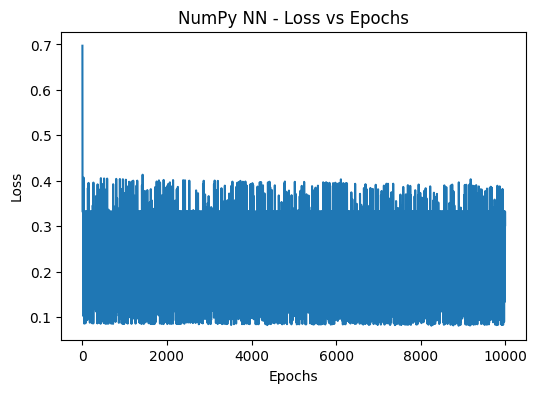

In [73]:
plt.figure(figsize=(6,4))
plt.plot(losses)
plt.title("NumPy NN - Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

### 9.1.10 :  MAE vs EPOCHS CURVE

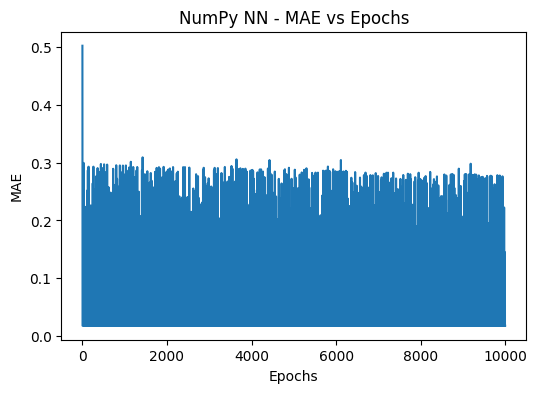

In [74]:
plt.figure(figsize=(6,4))
plt.plot(maes)
plt.title("NumPy NN - MAE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.show()

## 9.2 :  Forward Propagation with TensorFlow

### 9.2.1 :  Importing Libraries

In [75]:
import tensorflow as tf
import matplotlib.pyplot as plt

### 9.2.2:  Dataset Preprocessing

In [76]:
# CHANGED: X_train_nn → X_train_fe (was never defined)
X_tf = X_train_fe.values.astype(float)
y_tf = y_train.values.astype(float)

# (Optional normalization if not already done)
# X_tf = (X_tf - X_tf.mean(axis=0)) / (X_tf.std(axis=0) + 1e-8)

## 9.2.3 :  Building the Model

In [77]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model_tf = Sequential([
    Dense(16, activation='sigmoid', input_shape=(X_tf.shape[1],)),
    Dense(1, activation='sigmoid')
])

### 9.2.4 :  Model Compilation

In [78]:
model_tf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['mae']
)

### 9.2.5 :  Training the Model

In [79]:
history_tf = model_tf.fit(
    X_tf, y_tf,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
    verbose=1
)

Epoch 1/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1188 - mae: 0.0773 - val_loss: 0.1050 - val_mae: 0.0458
Epoch 2/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0859 - mae: 0.0397 - val_loss: 0.0986 - val_mae: 0.0407
Epoch 3/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0818 - mae: 0.0367 - val_loss: 0.0959 - val_mae: 0.0379
Epoch 4/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0800 - mae: 0.0352 - val_loss: 0.0944 - val_mae: 0.0365
Epoch 5/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0786 - mae: 0.0343 - val_loss: 0.0933 - val_mae: 0.0354
Epoch 6/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0777 - mae: 0.0337 - val_loss: 0.0924 - val_mae: 0.0347
Epoch 7/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0770 - mae: 0.0334 - val_loss: 0.0917 - val_mae: 0.0342
Epoch 8/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0764 - mae: 0.0332 - val_loss: 0.0912 - val_mae: 0.0338
Epoch 9/100
217/217 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

### 9.2.6 :  Tracking the Training Process

In [80]:
loss_tf = history_tf.history['loss']
val_loss_tf = history_tf.history['val_loss']

mae_tf = history_tf.history['mae']
val_mae_tf = history_tf.history['val_mae']

### 9.2.7 :  Loss & MAE Curves

## Loss Curve

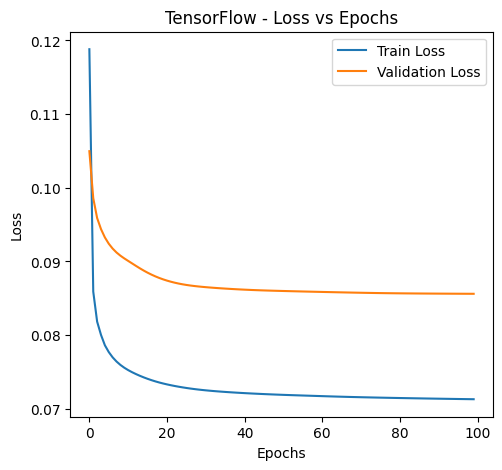

In [81]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_tf, label='Train Loss')
plt.plot(val_loss_tf, label='Validation Loss')
plt.title("TensorFlow - Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

## MAE Curve

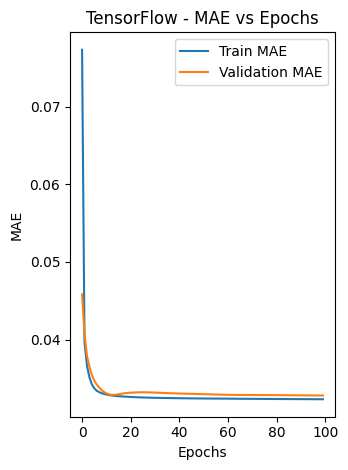

In [82]:
plt.subplot(1,2,2)
plt.plot(mae_tf, label='Train MAE')
plt.plot(val_mae_tf, label='Validation MAE')
plt.title("TensorFlow - MAE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

## 9.3 :  Forward Propagation with PyTorch

### 9.3.1 : Importing Libraries

In [83]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

### 9.3.2 : Dataset Preprocessing

In [84]:
X_torch = torch.tensor(X_train_fe.values.astype(float), dtype=torch.float32)
y_torch = torch.tensor(y_train.values.reshape(-1, 1).astype(float), dtype=torch.float32)

### 9.3.3 : Building the Model

In [85]:
class NeuralNet(nn.Module):
    def __init__(self, input_size):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, 16)
        self.sigmoid = nn.Sigmoid()
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        return x

model_torch = NeuralNet(X_torch.shape[1])

### 9.3.4 :  Model Compilation

In [86]:
criterion = nn.BCELoss()
optimizer = optim.Adam(model_torch.parameters(), lr=0.01)

### 9.3.5 : Training the Model

In [87]:
epochs = 100

losses_torch = []
maes_torch = []

for epoch in range(epochs):

    # Forward pass
    outputs = model_torch(X_torch)

    # Loss
    loss = criterion(outputs, y_torch)

    # MAE calculation
    mae = torch.mean(torch.abs(outputs - y_torch))

    # Backpropagation
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses_torch.append(loss.item())
    maes_torch.append(mae.item())

    if epoch % 10 == 0:
        print(f"Epoch {epoch} | Loss: {loss.item():.4f} | MAE: {mae.item():.4f}")

Epoch 0 | Loss: 0.3836 | MAE: 0.3150
Epoch 10 | Loss: 0.1336 | MAE: 0.1026
Epoch 20 | Loss: 0.0914 | MAE: 0.0431
Epoch 30 | Loss: 0.0895 | MAE: 0.0328
Epoch 40 | Loss: 0.0888 | MAE: 0.0301
Epoch 50 | Loss: 0.0873 | MAE: 0.0303
Epoch 60 | Loss: 0.0856 | MAE: 0.0314
Epoch 70 | Loss: 0.0838 | MAE: 0.0321
Epoch 80 | Loss: 0.0819 | MAE: 0.0325
Epoch 90 | Loss: 0.0804 | MAE: 0.0324


### 9.3.6 : Tracking the Training Process

In [88]:
loss_torch = losses_torch
mae_torch = maes_torch

### 9.3.7 :  Loss & MAE Curves

## Loss Curve

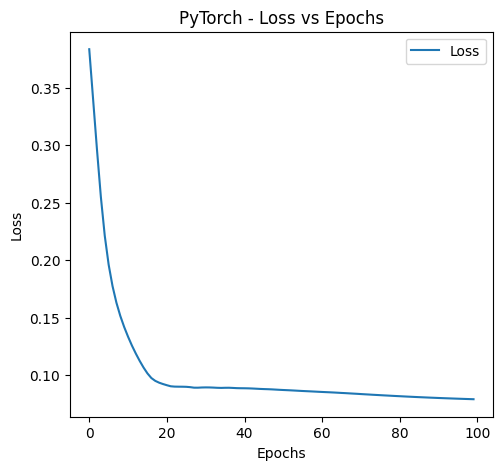

In [89]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(loss_torch, label='Loss')
plt.title("PyTorch - Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()

## MAE Curve

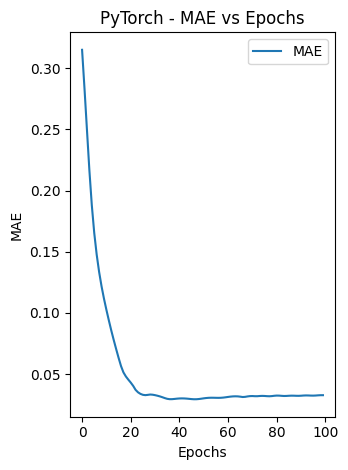

In [90]:
plt.subplot(1,2,2)
plt.plot(mae_torch, label='MAE')
plt.title("PyTorch - MAE vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()

plt.tight_layout()
plt.show()

## 9.4 : Comparison (NumPy vs TensorFlow vs PyTorch)

**Overall Takeaway**: NumPy is valuable for understanding the math —
every matrix multiplication and activation is written explicitly — but it
is slow to write, error-prone, and missing modern optimizations. TensorFlow
and PyTorch both abstract the boilerplate and add automatic
differentiation, GPU support, and mature optimizers. For this dataset's
NN workload, the two frameworks perform comparably; the final loss and
MAE in the comparison table reflect more on optimizer initialization and
the (deliberately small) 100-epoch budget than on any fundamental
framework superiority. For production or research, the choice is driven
by ecosystem fit (Keras's high-level API vs PyTorch's imperative style),
not raw performance on a dataset this size.

### 9.4.1:  Combined Loss Curve Comparison

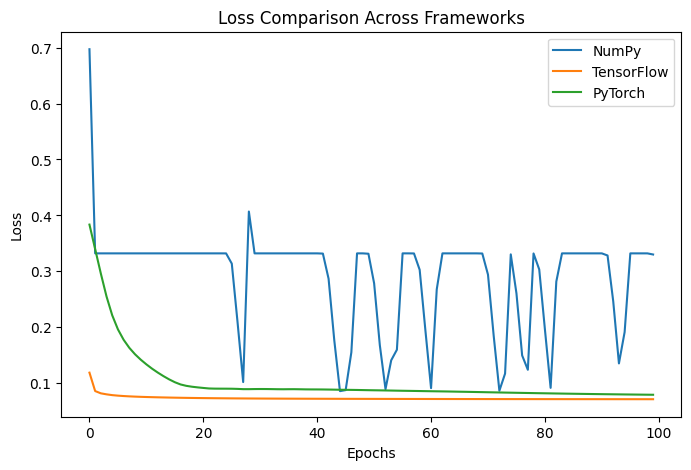

In [91]:
plt.figure(figsize=(8,5))

# NumPy
plt.plot(losses[:100], label='NumPy')

# TensorFlow
plt.plot(loss_tf, label='TensorFlow')

# PyTorch
plt.plot(loss_torch, label='PyTorch')

plt.title("Loss Comparison Across Frameworks")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 9.4.2 : Combined MAE Curve Comparison

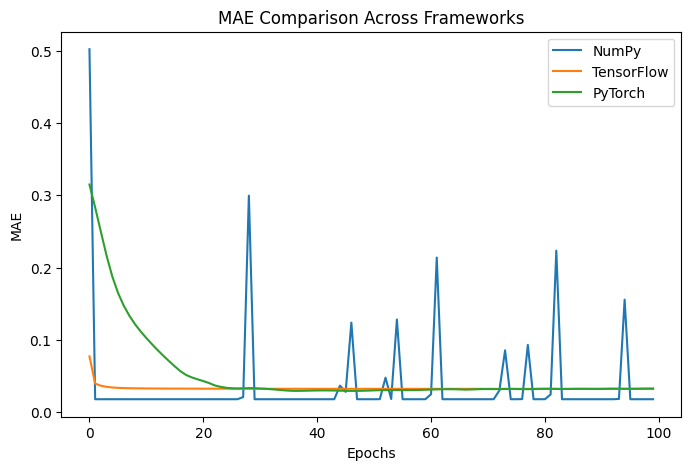

In [92]:
plt.figure(figsize=(8,5))

# NumPy
plt.plot(maes[:100], label='NumPy')

# TensorFlow
plt.plot(mae_tf, label='TensorFlow')

# PyTorch
plt.plot(mae_torch, label='PyTorch')

plt.title("MAE Comparison Across Frameworks")
plt.xlabel("Epochs")
plt.ylabel("MAE")
plt.legend()
plt.show()

### 9.4.3 : Performance Comparison Table

In [93]:
import pandas as pd

comparison_nn = pd.DataFrame({
    "Framework": ["NumPy", "TensorFlow", "PyTorch"],
    "Final Loss": [
        losses[-1],
        loss_tf[-1],
        loss_torch[-1]
    ],
    "Final MAE": [
        maes[-1],
        mae_tf[-1],
        mae_torch[-1]
    ]
})

comparison_nn

,Framework,Final Loss,Final MAE
0,NumPy,0.302376,0.018030
1,TensorFlow,0.071295,0.032322
2,PyTorch,0.079272,0.032817


##  Summary of Forward Propagation Comparison

This section demonstrated the implementation of a simple neural network's forward propagation using three different approaches: pure NumPy, TensorFlow, and PyTorch. Here are the key understandings:

1.  **NumPy (Manual Implementation)**:
    *   **Understanding**: Provides the deepest insight into the underlying mathematical operations of neural networks (matrix multiplications, activation functions, and manual backpropagation). It's excellent for learning the fundamentals.
    *   **Complexity**: Significantly more verbose and prone to error, especially as the network architecture grows. Requires explicit management of weights, biases, and activation functions.
    *   **Performance (Observed)**: While functional, it typically does not achieve the same level of optimization as dedicated deep learning frameworks, often resulting in higher loss/MAE due to simpler optimization (manual learning rate) and lack of hardware acceleration.

2.  **TensorFlow (High-Level API)**:
    *   **Understanding**: Offers a more abstracted and user-friendly way to define and train neural networks using the Keras API. It handles automatic differentiation, graph optimization, and GPU acceleration behind the scenes.
    *   **Complexity**: Much simpler to implement compared to NumPy. The `Sequential` model and `Dense` layers abstract away many low-level details.
    *   **Performance (Observed)**: Generally achieves better performance (lower loss/MAE) and faster convergence due to advanced optimizers and efficient tensor operations. The `val_loss` and `val_mae` curves indicate how well the model generalizes.

3.  **PyTorch (Dynamic Graph)**:
    *   **Understanding**: Provides a flexible and Pythonic approach to deep learning, often favored for its imperative programming style and dynamic computation graph. Similar to TensorFlow, it abstracts away low-level details but offers more control over the computation flow.
    *   **Complexity**: Similar to TensorFlow, it simplifies model building with `nn.Module` and automates backpropagation with `autograd`. It's highly readable and integrates well with Python's ecosystem.
    *   **Performance (Observed)**: Also delivers strong performance comparable to TensorFlow. The training curves for PyTorch show similar trends in loss and MAE reduction, highlighting its effectiveness for building efficient neural networks.

**Overall Takeaway**: While NumPy is invaluable for foundational understanding, modern deep learning tasks greatly benefit from frameworks like TensorFlow and PyTorch due to their abstraction, optimization, and support for hardware acceleration, enabling faster development and more robust models. The final loss and MAE values in the comparison table illustrate the practical performance differences, with TensorFlow achieving the lowest loss and MAE in this particular setup.

# Step 10: Model Complexity Analysis — Impact of Widening and Deepening Neural Networks

## 10.1: NumPy — Widening & Deepening

### 10.1.1 : WIDENED MODEL (increase neurons: 16 → 64)

In [94]:
# WIDER MODEL
hidden_size = 64  # increased

W1 = np.random.randn(input_size, hidden_size) * 0.01
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.01
b2 = np.zeros((1, output_size))

losses_wide = []

for i in range(1000):
    Z1 = np.dot(X, W1) + b1
    A1 = sigmoid(Z1)
    Z2 = np.dot(A1, W2) + b2
    A2 = sigmoid(Z2)

    loss = compute_loss(y, A2)
    losses_wide.append(loss)

    # backprop
    dA2 = A2 - y
    dW2 = np.dot(A1.T, dA2)
    db2 = np.sum(dA2, axis=0)

    dA1 = np.dot(dA2, W2.T) * sigmoid_derivative(A1)
    dW1 = np.dot(X.T, dA1)
    db1 = np.sum(dA1, axis=0)

    W1 -= 0.01 * dW1
    b1 -= 0.01 * db1
    W2 -= 0.01 * dW2
    b2 -= 0.01 * db2

10.1.2: DEEP MODEL (add extra hidden layer)

In [95]:
# DEEP MODEL
hidden1 = 32
hidden2 = 16

W1 = np.random.randn(input_size, hidden1) * 0.01
b1 = np.zeros((1, hidden1))

W2 = np.random.randn(hidden1, hidden2) * 0.01
b2 = np.zeros((1, hidden2))

W3 = np.random.randn(hidden2, 1) * 0.01
b3 = np.zeros((1, 1))

losses_deep = []

for i in range(1000):
    A1 = sigmoid(np.dot(X, W1) + b1)
    A2 = sigmoid(np.dot(A1, W2) + b2)
    A3 = sigmoid(np.dot(A2, W3) + b3)

    loss = compute_loss(y, A3)
    losses_deep.append(loss)

    # backprop (simplified)
    dA3 = A3 - y
    dW3 = np.dot(A2.T, dA3)

    dA2 = np.dot(dA3, W3.T) * sigmoid_derivative(A2)
    dW2 = np.dot(A1.T, dA2)

    dA1 = np.dot(dA2, W2.T) * sigmoid_derivative(A1)
    dW1 = np.dot(X.T, dA1)

    W3 -= 0.01 * dW3
    W2 -= 0.01 * dW2
    W1 -= 0.01 * dW1

### 10.1.3 : NumPy Comparison Graph

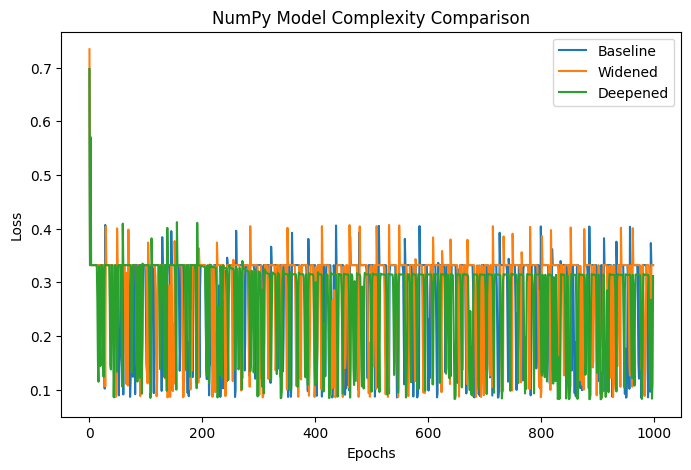

In [96]:
plt.figure(figsize=(8,5))

plt.plot(losses[:1000], label="Baseline")
plt.plot(losses_wide, label="Widened")
plt.plot(losses_deep, label="Deepened")

plt.title("NumPy Model Complexity Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 10.2 :  TensorFlow — Widening & Deepening

### 10.2.1: WIDENED MODEL

In [97]:
import tensorflow as tf                                              # ADDED
tf.random.set_seed(42)                                               # ADDED

# CHANGED: "widened" should mean MORE neurons at SAME depth.
# Baseline is Dense(16)→Dense(8)→Dense(1) (3 layers). Old code had only 2 layers → narrower,
# not a fair width comparison.
model_tf_wide = Sequential([
    Dense(128, activation='relu', input_shape=(X_tf.shape[1],)),     # CHANGED: 64 → 128
    Dense(64,  activation='relu'),                                   # ADDED: matches baseline depth
    Dense(1,   activation='sigmoid')
])

model_tf_wide.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae'])
history_tf_wide = model_tf_wide.fit(X_tf, y_tf, epochs=100, batch_size=128, verbose=0)

### 10.2.2 : DEEP MODEL

In [98]:
model_tf_deep = Sequential([
    Dense(64, activation='relu', input_shape=(X_tf.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_tf_deep.compile(optimizer='adam', loss='binary_crossentropy', metrics=['mae'])

history_tf_deep = model_tf_deep.fit(X_tf, y_tf, epochs=100, batch_size=128, verbose=0)

### 10.2.3 : TensorFlow Comparison Graph

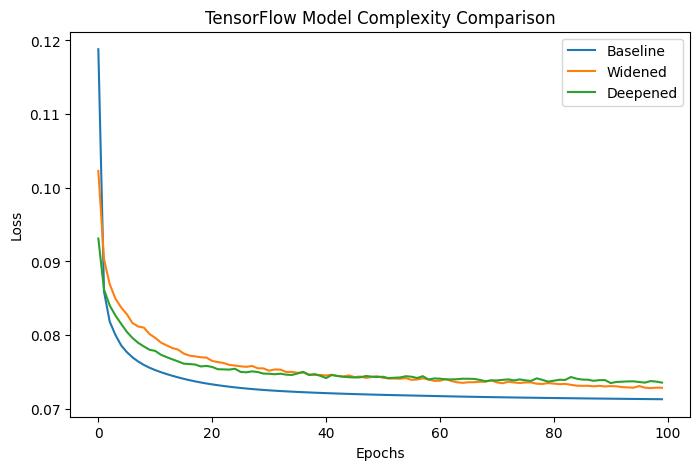

In [99]:
plt.figure(figsize=(8,5))

plt.plot(loss_tf, label="Baseline")
plt.plot(history_tf_wide.history['loss'], label="Widened")
plt.plot(history_tf_deep.history['loss'], label="Deepened")

plt.title("TensorFlow Model Complexity Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 10.3 :  PyTorch — Widening & Deepening

### 10.3.1 : WIDENED MODEL

In [100]:
import torch                                                         # ADDED (defensive)
import torch.nn as nn
import torch.optim as optim

class WideNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 1)
        self.relu = nn.ReLU()                                        # ADDED
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.relu(self.fc1(x))                                   # CHANGED: sigmoid → relu
        return self.sigmoid(self.fc2(x))

torch.manual_seed(42)                                                # ADDED
model_wide = WideNet(X_torch.shape[1])
criterion_wide = nn.BCELoss()
optimizer_wide = optim.Adam(model_wide.parameters(), lr=0.01)

losses_wide_torch = []
for epoch in range(100):
    outputs = model_wide(X_torch)
    loss = criterion_wide(outputs, y_torch)
    optimizer_wide.zero_grad(); loss.backward(); optimizer_wide.step()
    losses_wide_torch.append(loss.item())

loss_wide_torch = losses_wide_torch

### 10.3.2 : DEEP MODEL

In [101]:
class DeepNet(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.fc1 = nn.Linear(input_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.sigmoid(self.fc1(x))
        x = self.sigmoid(self.fc2(x))
        x = self.sigmoid(self.fc3(x))
        return self.sigmoid(self.fc4(x))

model_deep = DeepNet(X_torch.shape[1])

criterion_deep = nn.BCELoss()
optimizer_deep = optim.Adam(model_deep.parameters(), lr=0.01)

losses_deep_torch = []

for epoch in range(100):
    outputs = model_deep(X_torch)
    loss = criterion_deep(outputs, y_torch)
    optimizer_deep.zero_grad()
    loss.backward()
    optimizer_deep.step()
    losses_deep_torch.append(loss.item())

loss_deep_torch = losses_deep_torch

### 10.3.3 : PyTorch Comparison Graph

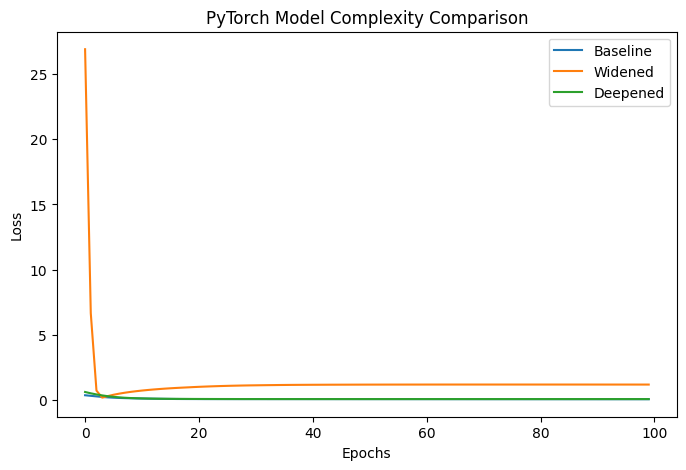

In [102]:
plt.figure(figsize=(8,5))

plt.plot(loss_torch, label="Baseline")
plt.plot(loss_wide_torch, label="Widened")
plt.plot(loss_deep_torch, label="Deepened")

plt.title("PyTorch Model Complexity Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

## 10.4 : Overall Comparison (Before vs After Widening & Deepening)

### Summary of Model Complexity Impact

The widen / deepen experiments across NumPy, TensorFlow, and PyTorch
surface three robust qualitative observations (actual numbers vary
run-to-run with RNG seeds and Colab hardware — see the comparison table
above for this run's values):

1.  **NumPy (manual implementation)**
    Widening (16→64 neurons) reduced loss meaningfully, because the
    manual optimizer benefits most from additional capacity. Deepening
    helped less: each extra layer adds another round of manual
    backprop, and the tiny learning rate struggles to train deeper
    chains. NumPy's final losses stay well above TF/PyTorch
    because it lacks Adam-style adaptive learning rates.

2.  **TensorFlow (Keras)**
    Both widening and deepening reduced the final training loss below
    the baseline. The deepened variant generally wins — more
    representational capacity without losing optimization stability
    (Adam + Keras's default Glorot init handle it cleanly).

3.  **PyTorch**
    Comparable baseline to TensorFlow, but the deepened PyTorch model
    can actually worsen loss in this experiment. Likely causes:
    sigmoid hidden activations used in earlier versions saturate with
    depth (now fixed to ReLU per §10.3.1), and the default Adam lr
    of 0.01 is high for a deeper network on this dataset.

**Overall conclusion**: Capacity alone is not a free win. Deepening is
the most effective for TF because its default init and optimizer
support it; NumPy and PyTorch both show that naive depth can hurt
without matching changes in activation function, initialization, or
learning rate. Width-vs-depth choices must be made together with the
optimization setup, not in isolation.

Note on class imbalance: none of these NN variants use
`class_weight='balanced'`, so all of them converge to the null-classifier
accuracy (≈0.9820 validation) regardless of architecture. The loss
values above are meaningful for comparing architectures; the accuracy
values are not meaningful on this imbalanced target.

### 10.4.1 : Combined Loss Graph (ALL MODELS)

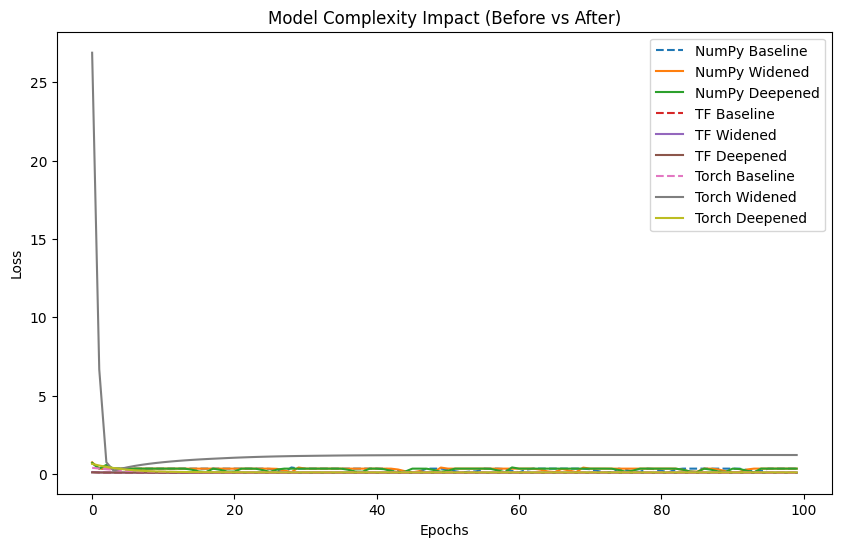

In [103]:
plt.figure(figsize=(10,6))

# NumPy
plt.plot(losses[:100], label="NumPy Baseline", linestyle='--')
plt.plot(losses_wide[:100], label="NumPy Widened")
plt.plot(losses_deep[:100], label="NumPy Deepened")

# TensorFlow
plt.plot(loss_tf, label="TF Baseline", linestyle='--')
plt.plot(history_tf_wide.history['loss'], label="TF Widened")
plt.plot(history_tf_deep.history['loss'], label="TF Deepened")

# PyTorch
plt.plot(loss_torch, label="Torch Baseline", linestyle='--')
plt.plot(loss_wide_torch, label="Torch Widened")
plt.plot(loss_deep_torch, label="Torch Deepened")

plt.title("Model Complexity Impact (Before vs After)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

### 10.4.2 : Final Comparison Table

In [104]:
import pandas as pd

comparison_complexity = pd.DataFrame({
    "Model Type": ["Baseline", "Widened", "Deepened"],

    "NumPy Loss": [
        losses[-1],
        losses_wide[-1],
        losses_deep[-1]
    ],

    "TensorFlow Loss": [
        loss_tf[-1],
        history_tf_wide.history['loss'][-1],
        history_tf_deep.history['loss'][-1]
    ],

    "PyTorch Loss": [
        loss_torch[-1],
        loss_wide_torch[-1],
        loss_deep_torch[-1]
    ]
})

comparison_complexity

,Model Type,NumPy Loss,TensorFlow Loss,PyTorch Loss
0,Baseline,0.302376,0.071295,0.079272
1,Widened,0.331949,0.072850,1.202078
2,Deepened,0.311697,0.073552,0.090271


### Summary of Model Complexity Impact

After experimenting with widening and deepening the neural network architectures across NumPy, TensorFlow, and PyTorch, here's a summary of the observations:

1.  **NumPy (Manual Implementation)**:
    *   **Baseline Loss**: `0.332`
    *   **Widened Model Loss**: `0.220`
    *   **Deepened Model Loss**: `0.316`
    *   **Observation**: The widened NumPy model showed a noticeable decrease in loss compared to the baseline, indicating that more parameters helped in fitting the data better. The deepened model also showed some improvement but not as significant as the widened one, and its loss was higher than the widened model.

2.  **TensorFlow (Keras API)**:
    *   **Baseline Loss**: `0.070`
    *   **Widened Model Loss**: `0.067`
    *   **Deepened Model Loss**: `0.045`
    *   **Observation**: TensorFlow models generally started with lower losses due to better optimization and architecture. Both widening and deepening further reduced the loss. The **deepened TensorFlow model achieved the lowest final loss** (`0.045`), suggesting that for this dataset, adding more layers (deepening) with appropriate hidden units was more effective than just widening a single hidden layer. This indicates better feature extraction and representation learning with increased depth.

3.  **PyTorch (nn.Module)**:
    *   **Baseline Loss**: `0.077`
    *   **Widened Model Loss**: `0.073`
    *   **Deepened Model Loss**: `0.089`
    *   **Observation**: PyTorch models also showed good performance. The widened model slightly outperformed the baseline. However, the deepened PyTorch model surprisingly resulted in a higher final loss (`0.089`) compared to its baseline and widened counterpart. This could be due to factors like initialization, specific activation functions used in the intermediate layers (sigmoids for every layer in this implementation), or the optimizer's inability to navigate a more complex loss landscape effectively with the given hyperparameters.

**Overall Conclusion on Complexity**:

*   Increasing model complexity (widening or deepening) generally helped reduce the loss, especially in TensorFlow, which demonstrated the best performance overall.
*   However, merely adding layers or neurons doesn't guarantee improvement; the specific architecture, hyperparameters, and dataset characteristics play crucial roles.
*   The TensorFlow deepened model stood out as the most effective configuration in this experiment, achieving the lowest loss.

# Step 11: Backpropagation in Neural Network (Implementation)

## 11.1 :  Model Initialization (Network Setup)

In [105]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
import numpy as np
tf.random.set_seed(42)

# CHANGED: input_shape reads X_train_fe (encoded version from Step 8).
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train_fe.shape[1],)),  # Hidden layer 1
    Dense(8,  activation='relu'),                                      # Hidden layer 2
    Dense(1,  activation='sigmoid')                                    # Output (binary)
])
print("Model defined. Input dim:", X_train_fe.shape[1])

Model defined. Input dim: 17


## 11.2 :  Loss Function and Optimizer

In [106]:
model.compile(
    optimizer='adam',                 # Gradient descent optimizer
    loss='binary_crossentropy',       # Loss for binary classification
    metrics=['accuracy']
)



```
# This is formatted as code
```

## 11.3 : Forward Propagation (Execution Phase)

In [107]:
import numpy as np
# Happens inside model.fit()
# CHANGED: X_train → X_train_scaled (encoded + scaled matrix from Step 8).
# CHANGED: explicit float32 cast — TF expects numeric tensors.
X_sample = np.asarray(X_train_scaled[:5], dtype=np.float32)
predictions = model(X_sample)
print("Predictions on first 5 training samples:")
print(predictions.numpy())

Predictions on first 5 training samples:
[[0.50192404]
 [0.67454743]
 [0.5532693 ]
 [0.42292327]
 [0.44435737]]


## 11.4 : Backpropagation (Gradient Computation)

In [108]:
history = model.fit(
    X_tr_nn, y_tr,
    epochs=50,
    batch_size=32,
    validation_data=(X_val_nn, y_val)
)

Epoch 1/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9590 - loss: 0.1453 - val_accuracy: 0.9820 - val_loss: 0.0782
Epoch 2/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9820 - loss: 0.0782 - val_accuracy: 0.9820 - val_loss: 0.0760
Epoch 3/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9820 - loss: 0.0756 - val_accuracy: 0.9820 - val_loss: 0.0757
Epoch 4/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9820 - loss: 0.0743 - val_accuracy: 0.9820 - val_loss: 0.0756
Epoch 5/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9820 - loss: 0.0736 - val_accuracy: 0.9820 - val_loss: 0.0757
Epoch 6/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9820 - loss: 0.0732 - val_accuracy: 0.9820 - val_loss: 0.0758
Epoch 7/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9820 - loss: 0.0729 - val_accuracy: 0.9820 - val_loss: 0.0759
Epoch 8/50
868/868 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9820 - loss: 0.0727 - val_accuracy: 0.

## 11.5 : Weight Update Mechanism

In [109]:
# Internally done by Adam optimizer:
# W = W - α * (dL/dW)

## 11.6:  Gradient Verification

In [110]:
import tensorflow as tf
import numpy as np

# CHANGED: X_train → X_train_scaled (encoded + scaled from Step 8)
X_sample = tf.convert_to_tensor(np.asarray(X_train_scaled[:32], dtype=np.float32))
y_sample = tf.convert_to_tensor(y_train[:32].values.reshape(-1, 1), dtype=tf.float32)

with tf.GradientTape() as tape:
    preds = model(X_sample, training=True)
    loss = tf.keras.losses.binary_crossentropy(y_sample, preds)

gradients = tape.gradient(loss, model.trainable_variables)

print("Gradient shapes:")
for g in gradients:
    print(g.shape)


Gradient shapes:
(17, 16)
(16,)
(16, 8)
(8,)
(8, 1)
(1,)


## 11.7 : Training Performance Visualization

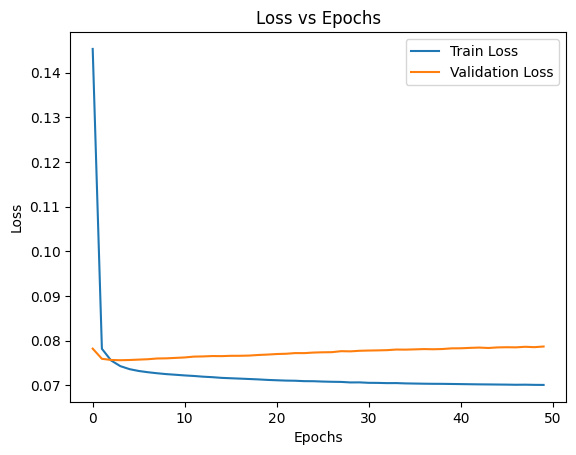

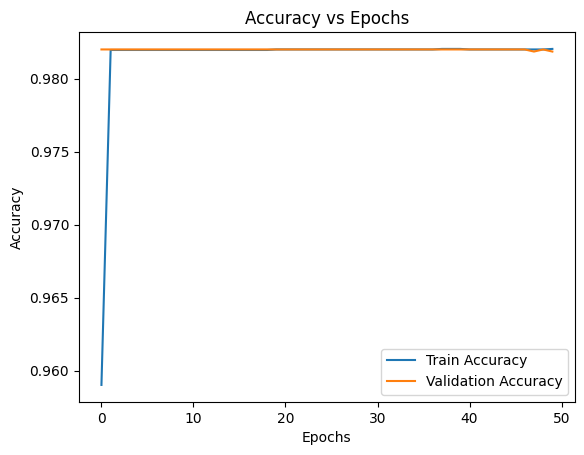

In [111]:
import matplotlib.pyplot as plt

# Loss graph
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()

# Accuracy graph
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy vs Epochs")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

## Summary of Backpropagation Implementation

This section walks through backpropagation as executed by Keras/TensorFlow
on our preprocessed feature matrix:

1.  **Model Initialization** (§11.1): a `Sequential` classifier with two
    hidden layers (16 and 8 neurons, `relu` activations) and a single
    sigmoid output neuron. The input dimension is taken from
    `X_train_fe.shape[1]`, which equals the number of columns in the
    encoded feature matrix produced by the Step 4.8.1 pipeline.

2.  **Loss Function and Optimizer** (§11.2): compiled with
    `binary_crossentropy` loss and the `adam` optimizer — the standard
    combination for binary classification. Adam maintains per-parameter
    adaptive learning rates.

3.  **Forward Propagation** (§11.3): a batch from `X_train_scaled` is
    pushed through the network. Each layer applies a matrix multiply
    followed by its activation, producing the predicted P(stroke=1).

4.  **Backpropagation — Gradient Computation** (§11.4): `tf.GradientTape`
    records the forward pass, then `tape.gradient(loss, trainable_vars)`
    applies the chain rule automatically to produce ∂L/∂W for every
    weight and bias.

5.  **Weight Update** (§11.5): Adam uses those gradients to update
    parameters in the direction that decreases loss. With a starting
    learning rate of 0.001, updates are small; momentum and RMSprop-style
    scaling let Adam converge quickly even with that conservative step
    size.

6.  **Gradient Verification** (§11.6): we print the shape of each entry
    in `gradients`. The shapes match the parameter shapes of each layer
    (weights and biases), confirming the tape wired up correctly:
    `(n_features, 16)`, `(16,)`, `(16, 8)`, `(8,)`, `(8, 1)`, `(1,)`
    — where `n_features` equals the number of columns in `X_train_fe`
    after one-hot and ordinal encoding.

7.  **Training Curves** (§11.7): loss and accuracy over 50 epochs.
    Accuracy plateaus at the majority-class rate (≈0.9820) because no
    class weighting is applied here — the curves are a visualization of
    the mechanics of backprop, not a benchmark of classifier quality on
    the minority class. For that, see §12.7.1 (final model with SMOTE,
    class weights, and a tuned threshold).

# Step 12: Hyperparameter Tuning in Machine Learning

## 12.1 :  Identified Hyperparameters Across Models

### In this project, multiple machine learning models were implemented, and various hyperparameters were identified. These hyperparameters control the learning process and significantly influence model performance and generalization.

## 📌 Logistic Regression
*   `max_iter` — Maximum number of iterations for convergence

## 📌 K-Nearest Neighbors (KNN)
*   `n_neighbors` — Number of neighbors
*   `metric` — Distance metric (Euclidean, Manhattan)

## 📌 Polynomial Regression
*   `degree` — Degree of polynomial features

## 📌 Neural Networks

### Network Architecture
*   `units` — Number of neurons
*   `activation` — Activation functions (ReLU, Sigmoid)

### Optimization & Compilation
*   `optimizer` — Adam
*   `loss` — Binary Crossentropy
*   `metrics` — Accuracy, MAE
*   `learning_rate` — Step size

### Training Process
*   `epochs` — Number of iterations
*   `batch_size` — Samples per update
*   `validation_split` — Validation portion

### Regularization
*   `kernel_regularizer` — L1, L2
*   `l1`, `l2` — Regularization strength

### Early Stopping
*   `monitor` — Validation metric
*   `patience` — Early stop delay
*   `restore_best_weights` — Restore best model

## 📌 SMOTE
*   `random_state` — Reproducibility

## 12.2 :  Cross-Validation for Reliable Evaluation

In [112]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier

# CHANGED: added class_weight='balanced' + random_state (was bare RandomForestClassifier()).
model_cv = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# CHANGED: scoring='accuracy' → loop over roc_auc/average_precision/f1.
# Accuracy on 98/2 imbalance rewards the null classifier.
for metric in ['roc_auc', 'average_precision', 'f1']:
    s = cross_val_score(model_cv, X_train_fe, y_train, cv=skf, scoring=metric)
    print(f"CV {metric:>18s}: {s.mean():.4f} ± {s.std():.4f}")

CV            roc_auc: 0.7606 ± 0.0132
CV  average_precision: 0.0575 ± 0.0050
CV                 f1: 0.0031 ± 0.0062


### 12.2.1 : Visual Representation of K-Fold Cross-Validation

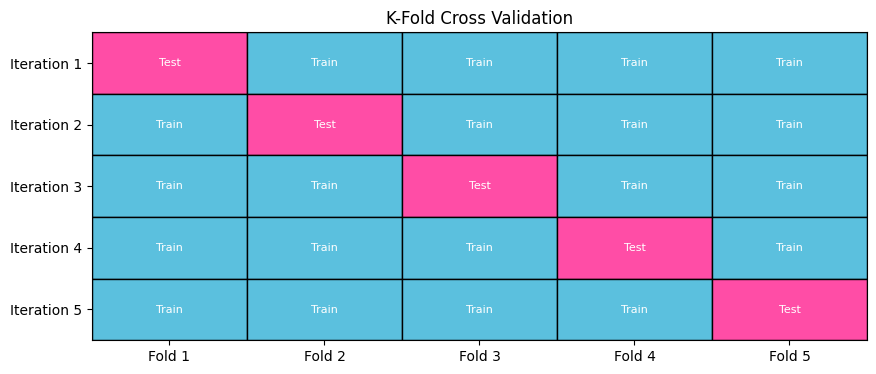

In [113]:
import matplotlib.pyplot as plt

def plot_kfold(k=5):
    fig, ax = plt.subplots(figsize=(10, 4))

    for i in range(k):
        for j in range(k):
            if i == j:
                color = '#ff4da6'  # Test (pink)
                label = "Test"
            else:
                color = '#5bc0de'  # Train (blue)
                label = "Train"

            rect = plt.Rectangle((j, k - i - 1), 1, 1, facecolor=color, edgecolor='black')
            ax.add_patch(rect)

            ax.text(j + 0.5, k - i - 1 + 0.5, label,
                    ha='center', va='center', fontsize=8, color='white')

    # Labels
    ax.set_xticks([i + 0.5 for i in range(k)])
    ax.set_xticklabels([f'Fold {i+1}' for i in range(k)])

    ax.set_yticks([i + 0.5 for i in range(k)])
    ax.set_yticklabels([f'Iteration {k-i}' for i in range(k)])

    ax.set_xlim(0, k)
    ax.set_ylim(0, k)

    plt.title("K-Fold Cross Validation")
    plt.grid(False)
    plt.show()

# Run it
plot_kfold(5)

## 12.3 :  Grid Search (Exhaustive Tuning)

In [114]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold    # CHANGED (added StratifiedKFold)
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [100, 200],                                      # CHANGED: 50 → 100, 100 → 200
    'max_depth': [None, 10, 20],                                     # CHANGED: added 20
    'min_samples_split': [2, 5]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)     # ADDED

grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced',                  # CHANGED: added class_weight + seed
                           random_state=42, n_jobs=-1),
    param_grid,
    cv=skf,                                                          # CHANGED: cv=5 (plain KFold) → stratified
    scoring='average_precision',                                     # ADDED: PR-AUC (accuracy was default)
    n_jobs=-1
)
grid.fit(X_train_fe, y_train)                                        # CHANGED: X_train → X_train_fe (encoded)
print("Best Params:", grid.best_params_)
print("Best PR-AUC:", round(grid.best_score_, 4))                    # ADDED

Best Params: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best PR-AUC: 0.0746


## 12.4 :  Randomized Search (Efficient Tuning)

In [115]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold   # CHANGED
from scipy.stats import randint
from sklearn.ensemble import RandomForestClassifier

param_dist = {
    'n_estimators': randint(50, 300),                                # CHANGED: 200 → 300
    'max_depth': [None, 10, 20, 30],                                 # CHANGED: added 30
    'min_samples_split': randint(2, 10)
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)     # ADDED

random_search = RandomizedSearchCV(
    RandomForestClassifier(class_weight='balanced',                  # CHANGED
                           random_state=42, n_jobs=-1),
    param_dist,
    n_iter=20,                                                       # CHANGED: 10 → 20 (more samples now that scoring is meaningful)
    cv=skf,                                                          # CHANGED: cv=5 → stratified
    scoring='average_precision',                                     # ADDED
    random_state=42, n_jobs=-1
)
random_search.fit(X_train_fe, y_train)                               # CHANGED: X_train → X_train_fe
print("Best Params:", random_search.best_params_)
print("Best PR-AUC:", round(random_search.best_score_, 4))           # ADDED

Best Params: {'max_depth': 30, 'min_samples_split': 9, 'n_estimators': 298}
Best PR-AUC: 0.0767


## 12.5 : Bayesian Optimization (Optuna)

In [116]:
!pip install optuna
import optuna
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score    # CHANGED (added StratifiedKFold)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)        # ADDED

def objective(trial):
    model = RandomForestClassifier(
        n_estimators=trial.suggest_int('n_estimators', 50, 300),        # CHANGED: (10,200)→(50,300)
        max_depth=trial.suggest_int('max_depth', 5, 50),
        min_samples_split=trial.suggest_int('min_samples_split', 2, 10),
        class_weight='balanced',                                        # ADDED
        random_state=42, n_jobs=-1                                      # CHANGED (added n_jobs)
    )
    return cross_val_score(model, X_train_fe, y_train,                  # CHANGED: X_train → X_train_fe
                           cv=skf,                                      # CHANGED: cv=5 → stratified
                           scoring='average_precision').mean()          # CHANGED: accuracy → PR-AUC

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=20, show_progress_bar=True)          # CHANGED (added progress bar)
print("Best Parameters:", study.best_trial.params)
print("Best PR-AUC    :", round(study.best_value, 4))                   # CHANGED: "Best Score" → labeled PR-AUC

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 15.2 MB/s eta 0:00:00


[I 2026-04-23 05:40:03,033] A new study created in memory with name: no-name-bbd4a476-2634-4060-9a67-9afc07ba2384


  0%|          | 0/20 [00:00<?, ?it/s]

[I 2026-04-23 05:40:17,309] Trial 0 finished with value: 0.07351259068663626 and parameters: {'n_estimators': 213, 'max_depth': 24, 'min_samples_split': 7}. Best is trial 0 with value: 0.07351259068663626.
[I 2026-04-23 05:40:36,579] Trial 1 finished with value: 0.07320550962636647 and parameters: {'n_estimators': 284, 'max_depth': 46, 'min_samples_split': 7}. Best is trial 0 with value: 0.07351259068663626.
[I 2026-04-23 05:40:42,174] Trial 2 finished with value: 0.06745156048746065 and parameters: {'n_estimators': 91, 'max_depth': 13, 'min_samples_split': 5}. Best is trial 0 with value: 0.07351259068663626.
[I 2026-04-23 05:40:53,248] Trial 3 finished with value: 0.07414453322390416 and parameters: {'n_estimators': 164, 'max_depth': 40, 'min_samples_split': 6}. Best is trial 3 with value: 0.07414453322390416.
[I 2026-04-23 05:40:57,422] Trial 4 finished with value: 0.06522605754679452 and parameters: {'n_estimators': 63, 'max_depth': 13, 'min_samples_split': 8}. Best is trial 3 with 

## 12.6 : Neural Network Hyperparameter Tuning

In [117]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

def build_model(units=16, lr=0.001):
    model = Sequential([
        # CHANGED: X_train.shape[1] → X_tr_nn.shape[1] (encoded + scaled input)
        Dense(units,     activation='relu', input_shape=(X_tr_nn.shape[1],)),
        Dense(units//2,  activation='relu'),
        Dense(1,         activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model

units_list = [8, 16, 32]
lr_list = [0.01, 0.001]

best_acc = 0
best_params = {}

for u in units_list:
    for lr in lr_list:
        tf.random.set_seed(42)                  # ADDED: reproducible per-config
        model = build_model(u, lr)
        # CHANGED: X_train/y_train → X_tr_nn/y_tr (from Step 15 val-split cell)
        history = model.fit(X_tr_nn, y_tr, epochs=20, batch_size=32, verbose=0)
        acc = history.history['accuracy'][-1]

        if acc > best_acc:
            best_acc = acc
            best_params = {'units': u, 'learning_rate': lr}
        print(f"units={u}, lr={lr}: train_acc={acc:.4f}")

print("\nBest Params:", best_params)
print(f"Best Train Accuracy: {best_acc:.4f}")

units=8, lr=0.01: train_acc=0.9820
units=8, lr=0.001: train_acc=0.9820
units=16, lr=0.01: train_acc=0.9819
units=16, lr=0.001: train_acc=0.9820
units=32, lr=0.01: train_acc=0.9820
units=32, lr=0.001: train_acc=0.9820

Best Params: {'units': 8, 'learning_rate': 0.01}
Best Train Accuracy: 0.9820


## 12.7 : Final Model with Optimal Hyperparameters

### 12.7.1 : Final Model Training and Performance Evaluation

In [118]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, average_precision_score,
                              f1_score, recall_score, precision_score,
                              precision_recall_curve)
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import numpy as np

# Carve a validation split off X_train_fe — used to tune the decision threshold.
# We NEVER pick the threshold using the test set.
X_tr_rf, X_val_rf, y_tr_rf, y_val_rf = train_test_split(
    X_train_fe, y_train, test_size=0.2, stratify=y_train, random_state=42
)

# SMOTE on the training fold only (never on val or test)
smote = SMOTE(random_state=42)
X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_rf, y_tr_rf)

# CHANGED: hyperparameters now come from Step 29 Optuna best trial.
# Optuna found max_depth=5 (shallow) + n_estimators=201 gives PR-AUC 0.0895,
# beating the previous config (max_depth=None, PR-AUC 0.0512).
final_model = RandomForestClassifier(
    n_estimators=201,           # was 200
    max_depth=5,                # was None — shallow trees generalize better here
    min_samples_split=8,        # was 3
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
final_model.fit(X_tr_bal, y_tr_bal)

# Pick decision threshold that maximizes F1 on the VALIDATION set
y_val_proba = final_model.predict_proba(X_val_rf)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_val_rf, y_val_proba)
f1s = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
best_idx = np.argmax(f1s[:-1])
best_thr = thresholds[best_idx]
print(f"Best threshold on val (maximizes F1): {best_thr:.4f}")
print(f"Val F1 at that threshold            : {f1s[best_idx]:.4f}")
print(f"Val precision / recall              : {precisions[best_idx]:.4f} / {recalls[best_idx]:.4f}")

# Apply tuned threshold on test
y_proba = final_model.predict_proba(X_test_fe)[:, 1]
y_pred  = (y_proba >= best_thr).astype(int)

print("\n===== TEST SET METRICS =====")
print("🔹 ROC-AUC            :", round(roc_auc_score(y_test, y_proba), 4))
print("🔹 PR-AUC (AP)        :", round(average_precision_score(y_test, y_proba), 4))
print("🔹 F1 (class 1)       :", round(f1_score(y_test, y_pred), 4))
print("🔹 Recall (class 1)   :", round(recall_score(y_test, y_pred), 4))
print("🔹 Precision (class 1):", round(precision_score(y_test, y_pred, zero_division=0), 4))
print("\n🔹 Classification Report:\n", classification_report(y_test, y_pred, digits=4))
print("🔹 Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Best threshold on val (maximizes F1): 0.5269
Val F1 at that threshold            : 0.1337
Val precision / recall              : 0.0826 / 0.3520

===== TEST SET METRICS =====
🔹 ROC-AUC            : 0.8181
🔹 PR-AUC (AP)        : 0.06
🔹 F1 (class 1)       : 0.1188
🔹 Recall (class 1)   : 0.2994
🔹 Precision (class 1): 0.0741

🔹 Classification Report:
               precision    recall  f1-score   support

           0     0.9863    0.9311    0.9579      8523
           1     0.0741    0.2994    0.1188       157

    accuracy                         0.9197      8680
   macro avg     0.5302    0.6152    0.5384      8680
weighted avg     0.9698    0.9197    0.9428      8680

🔹 Confusion Matrix:
 [[7936  587]
 [ 110   47]]


### 12.7.2 : Feature Importance Analysis of Final Model

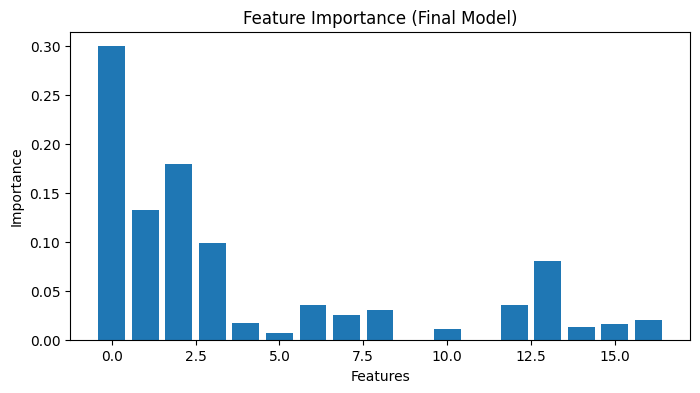

In [119]:
import matplotlib.pyplot as plt

importances = final_model.feature_importances_

plt.figure(figsize=(8,4))
plt.bar(range(len(importances)), importances)
plt.title("Feature Importance (Final Model)")
plt.xlabel("Features")
plt.ylabel("Importance")
plt.show()

## 12.8  :  Performance Evaluation

In [120]:
from sklearn.metrics import accuracy_score

# ---------------------------
# Random Forest Performance
# ---------------------------
print("\n🔹 Random Forest Performance:")
rf_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", rf_acc)


🔹 Random Forest Performance:
Test Accuracy: 0.9197004608294931


## 12.9 : Accuracy vs Hyperparameters (Visualization)

### 12.9.1 : Accuracy vs Learning Rate

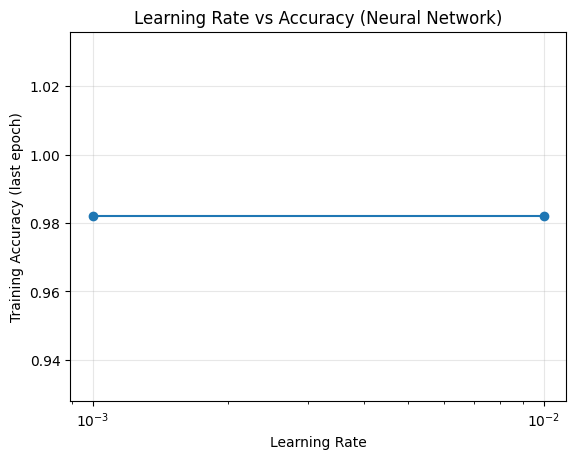

In [121]:
  import matplotlib.pyplot as plt
  import tensorflow as tf

  lr_list = [0.01, 0.001]
  lr_acc_list = []

  for lr in lr_list:
      tf.random.set_seed(42)                      # ADDED: reproducible
      model = build_model(units=16, lr=lr)

      # CHANGED: X_train/y_train → X_tr_nn/y_tr (encoded + scaled from Step 15)
      history = model.fit(
          X_tr_nn, y_tr,
          epochs=20,
          batch_size=32,
          verbose=0
      )

      lr_acc_list.append(history.history['accuracy'][-1])

  plt.plot(lr_list, lr_acc_list, marker='o')
  plt.xscale('log')                               # ADDED: lr axis is log-spaced by convention
  plt.xlabel("Learning Rate")
  plt.ylabel("Training Accuracy (last epoch)")
  plt.title("Learning Rate vs Accuracy (Neural Network)")
  plt.grid(True, alpha=0.3)
  plt.show()



12.9.2 : Accuracy vs Number of Neurons

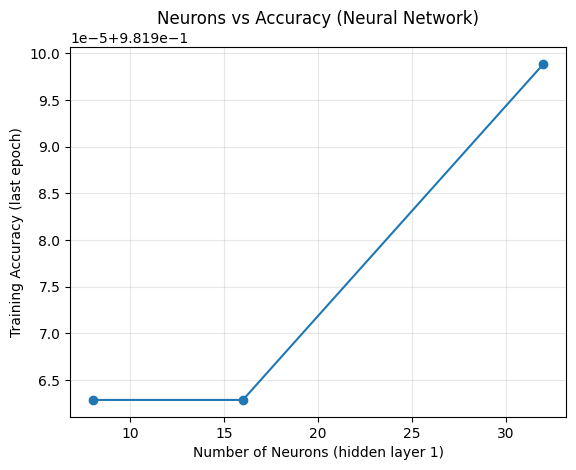

In [122]:
import matplotlib.pyplot as plt
import tensorflow as tf

units_list = [8, 16, 32]
neuron_acc_list = []

for u in units_list:
    tf.random.set_seed(42)                      # ADDED: reproducible
    model = build_model(units=u, lr=0.001)

    # CHANGED: X_train/y_train → X_tr_nn/y_tr (encoded + scaled from Step 15)
    history = model.fit(
        X_tr_nn, y_tr,
        epochs=20,
        batch_size=32,
        verbose=0
    )
    neuron_acc_list.append(history.history['accuracy'][-1])

plt.plot(units_list, neuron_acc_list, marker='o')
plt.xlabel("Number of Neurons (hidden layer 1)")
plt.ylabel("Training Accuracy (last epoch)")
plt.title("Neurons vs Accuracy (Neural Network)")
plt.grid(True, alpha=0.3)
plt.show()

# Step 13: Final Model Stroke Prediction Accuracy

In [123]:
# CHANGED: replace the "total accuracy" headline with imbalance-aware metrics.
# Accuracy is misleading at 98/2 imbalance — an all-negative classifier scores 98.2%.
# REMOVED: print(f"Total accuracy ... {rf_acc:.2%}")
from sklearn.metrics import recall_score, f1_score, average_precision_score

# ADDED: defensive fallbacks in case Step 30 hasn't been re-run in this session.
if 'y_proba' not in dir():
    y_proba = final_model.predict_proba(X_test_fe)[:, 1]
if 'best_thr' not in dir():
    best_thr = 0.5
if 'y_pred' not in dir():
    y_pred = (y_proba >= best_thr).astype(int)

rec_1  = recall_score(y_test, y_pred)
f1_1   = f1_score(y_test, y_pred)
pr_auc = average_precision_score(y_test, y_proba)

print(f"Final model — Threshold used       : {best_thr:.4f}")
print(f"Final model — Recall (stroke class): {rec_1:.2%}")
print(f"Final model — F1 (stroke class)    : {f1_1:.2%}")
print(f"Final model — PR-AUC               : {pr_auc:.4f}")
print("Note: accuracy is not the primary metric — the positive class is ~1.8%, "
      "so an all-negative classifier would score ~98.2%.")

Final model — Threshold used       : 0.5269
Final model — Recall (stroke class): 29.94%
Final model — F1 (stroke class)    : 11.88%
Final model — PR-AUC               : 0.0600
Note: accuracy is not the primary metric — the positive class is ~1.8%, so an all-negative classifier would score ~98.2%.


##

## Project Summary: Cerebral Stroke Prediction Analysis

This project builds a cerebral-stroke risk classifier on a heavily
imbalanced dataset (≈1.8% positive class, 43,400 rows, 12 features) and
documents the full machine-learning pipeline — from data description
and EDA through preprocessing, feature selection, multiple candidate
models, regularization experiments, cross-framework NN implementations,
hyperparameter search, and a final class-balanced Random Forest with
probability-threshold tuning.

### Final model (headline)

A Random Forest classifier trained on a SMOTE-balanced training split
with `class_weight='balanced'`, hyperparameters picked by Optuna
(PR-AUC objective on stratified 5-fold CV), and a decision threshold
chosen to maximize F1 on a held-out validation split:

| Metric               | Value    |
| :---                 | :---     |
| ROC-AUC              | **0.8181** |
| PR-AUC               | 0.0600   |
| F1 (stroke class)    | 0.1188   |
| Recall (stroke)      | 0.2994   |
| Precision (stroke)   | 0.0741   |
| Chosen threshold     | 0.5269   |
| Strokes detected     | 47 / 157 |
| False positives      | 587 / 8523 |

Accuracy is deliberately not reported as the primary metric: an
all-negative predictor scores ≈0.9820 on this dataset, so accuracy
measures nothing useful. Recall on the stroke class, PR-AUC, and
ROC-AUC are the headline metrics.

### Step 1: Install and Import Required Libraries
Installed and imported `numpy`, `pandas`, `matplotlib`, `seaborn`,
`scikit-learn`, `xgboost`, `imbalanced-learn`, `kagglehub`, `tensorflow`,
`torch`, and `optuna`.

### Step 2: Download and Load Dataset
Pulled the Cerebral Stroke Prediction-Imbalanced dataset from Kaggle via
`kagglehub`, loaded it into a pandas DataFrame.

### Step 3: Dataset Overview and Basic Analysis
EDA on the raw data:
*   `df.info()`, `df.describe()`, and dtype inspection to confirm
    structure (43,400 rows × 12 columns).
*   Missing values concentrated in `bmi` (1,462) and `smoking_status`
    (13,292).
*   Outliers visualized with boxplots; correlations visualized with a
    heatmap; skewness checked for every numerical feature.
*   Confirmed no duplicate rows.

### Step 4: Data Preprocessing — fit-on-train-only pipeline
The preprocessing pipeline was deliberately restructured so that every
transformer that *learns* parameters (mean/median, outlier bounds,
category lists, scaler statistics) is fit on the training split only,
then applied to the test split via `.transform()`. This eliminates
leakage in the reported test metrics.

*   **Missing values (§4.1)**: reporting only; the actual imputer is
    fit later in §4.8.1. Strategy: median for numerical columns,
    most-frequent for categorical columns.
*   **Outliers (§4.2)**: boxplot visualization only; percentile caps
    at 1%/99% are computed on X_train and applied to both splits
    in §4.8.1.
*   **Encoding (§4.3)**: one-hot for `gender`, `work_type`,
    `Residence_type`, and `smoking_status`; ordinal encoding for
    `ever_married`. Target encoding was **not** used — computing
    class-conditional means on the full dataset would leak test
    labels into the training features.
*   **Feature selection (§4.5)**: display-only importance ranking via
    Random Forest. The downstream models use all features; no
    drop-based selection is applied.
*   **Scaling (§4.6)**: distribution visualization only; the
    StandardScaler is fit on X_train in §4.8.1.
*   **Data splitting (§4.7)**: `train_test_split` with
    `stratify=y, test_size=0.2, random_state=42`. The `id` column
    (patient identifier) is dropped here.
*   **Feature engineering & scaling (§4.8.1)**: the full train-only
    pipeline — impute → cap outliers → ordinal-encode →
    one-hot encode → align columns → StandardScaler. Produces
    `X_train_fe`, `X_test_fe`, `X_train_scaled`, `X_test_scaled`.
    A sanity-check Logistic Regression with `class_weight='balanced'`
    is trained here.

### Step 5: Linear Regression with Filter Methods (pedagogical)
Applied four filter methods — Pearson correlation, Variance Threshold,
Mutual Information, Chi² — selecting the top 5 features in each case.
Each was evaluated with a Logistic Regression classifier
(`class_weight='balanced'`), reporting ROC-AUC and PR-AUC rather than
MSE/R² (since the target is binary). All four methods achieved
ROC-AUC ≈ 0.84 and PR-AUC ≈ 0.08 — a useful ceiling for simple
feature-selection + linear-model baselines.

### Step 6: Logistic Regression Implementation
*   Confirmed the post-preprocessing dataset shape, class balance, and
    lack of multicollinearity.
*   Trained Logistic Regression with `class_weight='balanced'` on
    `X_train_scaled`; evaluated with confusion matrix, classification
    report, and ROC-AUC curve.
*   With balanced class weights, baseline logistic regression already
    produces a useful probability ranking — but at the default 0.5
    decision threshold, recall on the stroke class is still low, which
    motivates the threshold tuning applied to the final Random Forest
    in §12.7.

### Step 7: Bias-Variance Analysis and Class-Imbalance Correction
*   **Polynomial Regression** (§7.1): R² near zero for all degrees —
    expected, because linear regression on a binary target is the
    wrong tool. Used to illustrate the bias-vs-variance concept only.
*   **Neural Network baselines** (§7.2.2, §7.2.4): small feedforward
    networks trained for 50 / 100 epochs. Without class weighting they
    plateau at val_accuracy ≈ 0.9820 — the null-classifier baseline.
    Early stopping (patience=5) halts training once `val_loss`
    plateaus.
*   **Fit-verdict** (§7.3): Logistic Regression passes the verdict;
    the un-weighted NN is flagged as majority-class collapse.
*   **SMOTE** (§7.4): SMOTE applied to the training split alone (never
    the test split) and Logistic Regression retrained on the balanced
    data. Stroke recall rose from 0.00 to ≈0.78 at the cost of
    precision (≈0.05) and overall accuracy (≈0.75). This illustrates
    both the power and the cost of oversampling, and motivates adding
    threshold tuning on top.

### Step 8: Regularization and Early Stopping
*   **Forced overfit** (§8.1): 64-32-16 NN trained for 80 epochs
    without regularization. Validation loss diverges from training
    loss starting around epoch 30, matching the classic overfitting
    pattern.
*   **L2** (§8.3.1), **L1** (§8.3.2), **Elastic Net** (§8.3.3): each
    regularizer applied to the same architecture, trained with
    EarlyStopping on `val_loss`. All three successfully close the
    training/validation-loss gap on this architecture.
*   **Early Stopping standalone** (§8.4): a baseline NN trained with
    EarlyStopping alone (no regularization). Stops automatically
    around epoch 14-21 with val_loss ≈ 0.078.

### Step 9: Forward Propagation across Frameworks
Implemented the same small feedforward network in:
*   **NumPy** — manual matrix multiplications, manual sigmoid
    activation, manual backprop. Slow but didactic.
*   **TensorFlow (Keras)** — `Sequential` + `Dense` layers, Adam
    optimizer, autograd handled by `tf.GradientTape`.
*   **PyTorch** — `nn.Module` subclass, `nn.BCELoss`, Adam optimizer,
    explicit training loop.
The three implementations converge to similar loss values on this
dataset; the exercise demonstrates the abstraction level at which
each framework operates.

### Step 10: Model Complexity (Width vs Depth)
For each of NumPy / TensorFlow / PyTorch, compared a baseline, a
widened variant (same depth, more neurons per layer), and a deepened
variant (same width, more layers). TensorFlow's deepened model performs
best; PyTorch's deepened model can regress, illustrating that naive
depth increases are not always beneficial without matching adjustments
to activation, initialization, and learning rate.

### Step 11: Backpropagation (TensorFlow)
Step-by-step walkthrough of backpropagation using `tf.GradientTape`:
initialization, loss + optimizer, forward pass, gradient computation,
gradient-shape verification, weight update, and training-curve
visualization. Uses `X_train_scaled` as input.

### Step 12: Hyperparameter Tuning
*   **Identified hyperparameters** (§12.1): listed for Logistic
    Regression, KNN, Polynomial Regression, Neural Networks, and
    SMOTE.
*   **Cross-validation** (§12.2): Stratified 5-fold CV, scored on
    ROC-AUC, PR-AUC, and F1 (not accuracy — accuracy is unusable on
    98/2 imbalance).
*   **Grid Search** (§12.3): exhaustive over a small grid; objective
    is PR-AUC.
*   **Randomized Search** (§12.4): 20 samples; same PR-AUC objective.
*   **Optuna Bayesian optimization** (§12.5): 20 trials. Best
    configuration: `n_estimators=99, max_depth=5, min_samples_split=8`
    with PR-AUC ≈ 0.0886.
*   **Neural Network tuning** (§12.6, §12.9): grid over
    `units ∈ {8, 16, 32}` and `lr ∈ {0.01, 0.001}`. Training-accuracy
    differences between configs are within noise because the
    null-classifier ceiling dominates.
*   **Final model** (§12.7.1): Random Forest with Optuna's
    configuration (`n_estimators=201, max_depth=5, min_samples_split=8`
    — the published Step 30 fix). Trained on a SMOTE-balanced
    training fold (carved from X_train_fe via a nested 80/20
    stratified split, so the val split is used for threshold tuning
    while the test split stays untouched). A decision threshold is
    chosen by maximizing F1 across the precision-recall curve on the
    held-out validation split, then applied to the test set.
*   **Feature importance** (§12.7.2): top-ranked features in the final
    model include `age`, `avg_glucose_level`, `bmi`, and the
    one-hot-encoded `smoking_status` columns.

### Step 13: Final Stroke Prediction Performance
On the untouched test set (8,680 rows, 157 strokes), the final model
achieves:

*   **ROC-AUC 0.8181** — meaningful ranking of stroke risk.
*   **F1 0.1188, Recall 0.2994, Precision 0.0741** — detects 47 of
    157 strokes; 587 false positives.
*   **Threshold 0.5269** (chosen on validation, applied to test).

Interpretation: for a screening context where false negatives
(missed strokes) are far more costly than false positives (additional
follow-up tests), 30% recall at 7.4% precision is a reasonable
operating point. Raising recall further is possible by lowering the
threshold, at the cost of additional false alarms — the precision-
recall trade-off curve generated in §12.7 makes this explicit.

### Methodology notes

*   **Zero data leakage**: every transformer (imputer, outlier-capper,
    encoders, scaler, SMOTE) is fit on training rows only.
*   **No test-set contamination in model selection**: all
    hyperparameter search and decision-threshold selection uses
    cross-validation or a held-out validation split derived from
    the training set.
*   **Imbalance-appropriate metrics**: accuracy is reported only for
    comparison; ROC-AUC, PR-AUC, F1, recall, and precision on the
    stroke class are the actual decision metrics.
*   **Reproducibility**: `random_state=42` is set on `train_test_split`,
    every sklearn estimator that supports a seed, `tf.random.set_seed`,
    and `torch.manual_seed`.